In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Que no haya límite en número de columnas
pd.set_option('display.max_columns', None)

# Ajustes opcionales para que no quiebre líneas
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

## Funciones

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import colors as mcolors

# Estilo seaborn para la figura
sns.set_style("whitegrid")
sns.set_context("talk")

def plot_metric_grid_all(
        df_full,
        df_only_coreset,
        df_latent,
        df_latent_ft,
        df_TDColer=pd.DataFrame(),
        spaces=('original', 'latent'),
        max_ipc=100,
        metric='test_balanced',
        methods=('k-means', 'k-center', 'ag'),
        models=None,
        x_label='Instances Per Class',
        y_label='Test balanced',
        name_savefig='figura.png'
    ):
    """
    Grid dinámico metric vs IPC:
      • Filas → cada modelo de `models`.
      • Columnas → bloques por espacio (cada bloque = len(methods) columnas).
    Fondo de cada bloque coloreado según espacio (original / latent).
    Dentro de cada celda:
      - Curvas media±std de cada técnica (Original, CorVAE, TDColer).
      - Línea base full-data.
      - Cuadro con valor Full-data y máximo de CorVAE.
    """

    

    # 1) Unir DataFrames con columna 'space' y 'technique'
    df_list = []
    for space in spaces:
        d_latent = df_latent[df_latent['space'] == space]
        d_tdcol  = df_TDColer[df_TDColer['space'] == space] if not df_TDColer.empty else pd.DataFrame()
        for src, tech in [
            (df_only_coreset, 'Original'),
            (d_latent,       'CorVAE'),
            #(df_latent_ft,  'latent_ft'),
            (d_tdcol,        'TDColer'),
        ]:
            if src.empty:
                continue
            tmp = src.copy()
            tmp['technique'] = tech
            tmp['space']     = space
            df_list.append(tmp)

    df_all = pd.concat(df_list, ignore_index=True)
    df_all = df_all[df_all['IPC'] <= max_ipc]

    # 2) Preparo figura y ejes
    n_rows = len(models)
    n_cols = len(spaces) * len(methods)
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4*n_cols, 3*n_rows),
        sharex=True, sharey=True
    )
    axes = np.array(axes).reshape(n_rows, n_cols)

    # Paleta fija para líneas
    tech_colors = {
        'Original': 'C0',
        'CorVAE':   'C2',
        'TDColer':  'C4',
    }
    baseline_color = 'gray'

    # Paleta pastel para fondos de espacios
    bg_palette = sns.color_palette("pastel", len(spaces))
    bg_colors  = dict(zip(spaces, bg_palette))

    # 3) Rellenar cada subplot
    for i, model in enumerate(models):
        for k, space in enumerate(spaces):
            for j, method in enumerate(methods):
                col = k * len(methods) + j
                ax = axes[i, col]

                # Sombreado de fondo según espacio
                rgba = mcolors.to_rgba(bg_colors[space], alpha=0.1)
                ax.set_facecolor(rgba)

                sub = df_all[
                    (df_all['model']  == model) &
                    (df_all['method'] == method) &
                    (df_all['space']  == space)
                ]
                if sub.empty:
                    ax.set_visible(False)
                    continue

                ax.set_title(f"{model} – {method}", loc='left', pad=6)

                # Dibujar curvas y calcular máximo de CorVAE
                corvae_max_val = None
                corvae_max_ipc = None
                for tech, color in tech_colors.items():
                    sp = sub[sub['technique'] == tech]
                    if sp.empty:
                        continue
                    #print(sp)
                    grp = sp.groupby('IPC')[metric].agg(['mean','std']).reset_index()
                    ax.plot(grp['IPC'], grp['mean'],
                            marker='o', label=tech, color=color)
                    ax.fill_between(
                        grp['IPC'],
                        grp['mean'] - grp['std'],
                        grp['mean'] + grp['std'],
                        alpha=0.2, color=color
                    )
                    # si es CorVAE, calcular su máximo
                    if tech == 'CorVAE':
                        idx = grp['mean'].idxmax()
                        corvae_max_val = grp.at[idx, 'mean']
                        corvae_max_ipc = grp.at[idx, 'IPC']

                # Línea base full-data
                baseline = df_full[df_full['model'] == model][metric].mean()
                ax.axhline(y=baseline,
                           linestyle='--',
                           color=baseline_color,
                           label='Full-data')

                ax.grid(True, linestyle='--', alpha=0.5)
                ax.set_xlim(0, max_ipc)

    fig.supxlabel(x_label, fontsize=14)
    fig.supylabel(y_label, fontsize=14, rotation='vertical', x=0.02)

    # Leyenda global (manual, sin solape)
    from matplotlib.lines import Line2D

    legend_elements = [
        Line2D([0], [0], marker='o', color=tech_colors['Original'], label='Original'),
        Line2D([0], [0], marker='o', color=tech_colors['CorVAE'],   label='CorVAE'),
        Line2D([0], [0], linestyle='--', color=baseline_color,      label='Full-data'),
    ]

    if 'TDColer' in df_all['technique'].unique():
        legend_elements.append(
            Line2D([0], [0], marker='o', color=tech_colors['TDColer'], label='TDColer')
        )

    fig.legend(
        handles=legend_elements,
        loc='upper center',
        ncol=len(legend_elements),
        #title='Técnica',
        bbox_to_anchor=(0.5, 1.03),  # sube un poco más la leyenda
        fontsize=12,
        title_fontsize=13
    )

    # Ajustar layout para no solapar
    plt.tight_layout(rect=[0, 0, 1, 0.97])  # más espacio arriba
    plt.savefig(name_savefig, dpi=300, bbox_inches='tight')
    plt.show()


In [4]:

def plot_metric_grid(df_random,
                     df_original,
                     df_latent,
                     df_latent_ft,
                     space='original',
                     max_ipc=100,
                     metric='test_balanced',
                     x_label='Instances Per Class',
                     y_label='Test balanced',
                     methods=['k-means',
                              'k-center',
                              'ag'
                              ]):
    """
    Dibuja en una única figura (grid) la curva de `metric` vs IPC
    para cada combinación (método, modelo).  
    Filas → modelos, Columnas → métodos.  
    Dentro de cada celda: las tres técnicas de distilación
    (original, latent, latent_ft) con media ± std, y línea base Full-data.
    """

    df_latent = df_latent[df_latent['space'] == space]
    df_latent_ft = df_latent_ft[df_latent_ft['space'] == space]

    # 1) Concatena solo los tres DataFrames de distilación
    dfs = [
        (df_original.copy(),  'original'),
        (df_latent.copy(),    'latent'),
        (df_latent_ft.copy(), 'latent_ft'),
    ]
    df_list = []
    for df, tech in dfs:
        df['technique'] = tech
        df_list.append(df)
    df_all_init = pd.concat(df_list, ignore_index=True)

    df_all = df_all_init[df_all_init['IPC'] <= max_ipc]

    # 3) Métodos y modelos para el grid
    #methods = sorted([m for m in df_all['method'].unique()
    #                  if m not in ['random', 'Full-data']])
    models  = sorted(df_all['model'].unique())

    # Swap: filas = modelos, columnas = métodos
    n_rows, n_cols = len(models), len(methods)
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(4*n_cols, 3*n_rows),
                             sharex=True, sharey=True)

    # 4) Paleta para las tres técnicas
    palette = {
        'original':  'C0',
        'latent':    'C2',
        'latent_ft': 'C3',
        'TDColer':   'C4',
    }

    # 5) Rellenar cada celda
    for i, model in enumerate(models):
        for j, method in enumerate(methods):
            ax = axes[i, j] if n_rows > 1 and n_cols > 1 else (
                 axes[j] if n_rows == 1 else axes[i])
            
            

            sub = df_all[
                (df_all['method'] == method) &
                (df_all['model']  == model)
            ]
            if sub.empty:
                ax.set_visible(False)
                continue

            # Título interno de cada subplot
            ax.set_title(f"{model} – {method}", loc='left', pad=10)

            # Dibujar las curvas de cada técnica
            for tech, color in palette.items():
                sp = sub[sub['technique'] == tech]
                if sp.empty:
                    continue
                grp = (sp
                       .groupby('IPC')[metric]
                       .agg(['mean', 'std'])
                       .reset_index())
                ax.plot(grp['IPC'], grp['mean'],
                        marker='o', label=tech, color=color)
                ax.fill_between(
                    grp['IPC'],
                    grp['mean'] - grp['std'],
                    grp['mean'] + grp['std'],
                    alpha=0.2, color=color
                )

            # Línea base para 'Full-data'
            baseline_df = df_all_init[
                (df_all_init['method'] == 'Full-data') &
                (df_all_init['model']  == model)
            ]
            if not baseline_df.empty:
                baseline_val = baseline_df[metric].mean()
                ax.axhline(
                    y=baseline_val,
                    linestyle='--',
                    color='gray',
                    label='Full-data'
                )

            ax.grid(True, linestyle='--', alpha=0.5)
            ax.set_xlim(0, max_ipc)

    # 6) Etiquetas globales de ejes
    # Para Matplotlib >= 3.4 puedes usar:
    fig.supxlabel(x_label, fontsize=14)
    fig.supylabel(y_label, fontsize=14, rotation='vertical', x=0)

    # 7) Leyenda común arriba
    # Tomamos los handles/labels del último ax válido
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels,
               loc='upper center', ncol=len(palette)+1,
               title="Técnica")
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

## Creación del dataset

In [4]:


def rename_rows(df, column, mapping):
    """
    Renombra las filas de un DataFrame para que coincidan con el método.
    """
    df = df.copy()

    # Aplicamos el cambio en el DataFrame
    df[column] = (df[column]
                .replace(mapping)                # reemplaza los que estén en el dict
                #.str.lower()                     # opcional: pasar todo a minúsculas
                )
    return df

def preprocess_baseline(df):
    df = df[['Classifier','Encoder','Data Parse Mode','Distill Method','Distill Space',
             'Output Space','Convert Binary','Cluster Center','N','Score']]
    
    mapping_classifier = {
        'XGBClassifier':       'xgb',
        'MLPClassifier':  'mlp',
        'KNeighborsClassifier':'knn',
        'GaussianNB': 'naive_bayes',
        'LogisticRegression': 'logreg',
    }

    mapping_method = {
        'KMeans':       'k-means',
        'Agglo':  'ag',
    }

    mapping_space = {
        'decoded':       'original',
        'encoded':  'latent',

    }

    df = rename_rows(df, 'Classifier', mapping_classifier)
    df = rename_rows(df, 'Distill Method', mapping_method)
    df = rename_rows(df, 'Output Space', mapping_space)

    df.rename(columns={'N': 'IPC',
                       'Distill Method':'method',
                       'Classifier':'model',
                       'Score':'test_balanced',
                       'Output Space':'space'
                       
                       }, inplace=True)

    df_full = df[
                        (df['Data Parse Mode'] == 'mixed') &
                        (df['method'] == 'Original') &
                        (df['Convert Binary'] == False)
                    ]
    
    df_only_coreset = df[
                        (df['method'].isin(['k-means', 'ag'])) &
                        (df['Distill Space'] == 'original') &
                        (df['space'] == 'original') &
                        (df['Convert Binary'] == False) &
                        (df['Cluster Center'] == 'centroid') 
                    ]
                    
    df_latent = df[
                        (df['method'].isin(['k-means', 'ag'])) &
                        (df['Distill Space'] == 'encoded') &
                        (df['Convert Binary'] == False) &
                        (df['Encoder'] == 'TF')
                    ]
    df_latent_ft = df[
                        (df['method'].isin(['k-means', 'ag'])) &
                        (df['Distill Space'] == 'encoded') &
                        (df['Convert Binary'] == False) &
                        (df['Encoder'] == 'TF-MultiHead')
                    ]

    df_full = df_full[['model','method','IPC','test_balanced','space']]
    df_only_coreset = df_only_coreset[['model','method','IPC','test_balanced','space']]
    df_latent = df_latent[['model','method','IPC','test_balanced','space']]
    df_latent_ft = df_latent_ft[['model','method','IPC','test_balanced', 'space']]

    return df_full,df_only_coreset,df_latent, df_latent_ft

In [5]:
# Preprocesamiento del dataset de TDColer

df_tdcoler_adult = pd.read_csv('TDCOLER_adult.csv')
df_tdcoler_default = pd.read_csv('TDCOLER_default.csv')

(df_tdcoler_full_adult, df_tdcoler_only_coreset_adult, 
 df_tdcoler_latent_adult, df_tdcoler_latent_ft_adult) = preprocess_baseline(df_tdcoler_adult)

(df_tdcoler_full_default, df_tdcoler_only_coreset_default, 
 df_tdcoler_latent_default, df_tdcoler_latent_ft_default) = preprocess_baseline(df_tdcoler_default)

### Dataset de adult

In [6]:
df_only_coreset_adult = pd.read_csv('../BACKUP/Experiments_F_H/checkpoint_adult_Doriginal_G/metrics.csv')
df_only_coreset_adult['method'] = df_only_coreset_adult['method'].replace(
     'k_center', 'k-center'
)
df_full_adult = df_only_coreset_adult[df_only_coreset_adult['method'] == 'Full-data']
# df_latent_adult = pd.read_csv('Experiments_M/checkpoint_shoppers_Dlatent_F/metrics.csv')
# df_latent_ft_adult = pd.read_csv('Experiments_M/checkpoint_shoppers_Dlatent_ft_F/metrics.csv')
df_latent_adult = pd.read_csv('Experiments_M/checkpoint_adult_Dlatent_G/metrics.csv')
df_latent_ft_adult = pd.read_csv('Experiments_M/checkpoint_adult_Dlatent_ft_G/metrics.csv')

In [7]:
df_only_coreset_adult

,model,method,cv_balanced,cv_macro_f1,cv_weighted_f1,cv_accuracy,cv_balanced_std,cv_macro_f1_std,cv_weighted_f1_std,cv_accuracy_std,optuna_time,train_time,test_balanced,test_macro_f1,test_weighted_f1,test_accuracy,test_roc_auc,inf_time_per_sample,space,IPC,seed,vae_pretrain_time,vae_fine_tunning_time,encoder_inference_time,decoder_inference_time
0,xgb,Full-data,0.798,0.815,0.869,0.872,0.004,0.005,0.004,0.004,72.189,140.422,0.802,0.818,0.871,0.875,0.927,0.000009,original,NaN,NaN,NaN,NaN,NaN,NaN
1,rf,Full-data,0.831,0.781,0.827,0.817,0.001,0.002,0.002,0.002,695.289,39.006,0.829,0.783,0.830,0.820,0.912,0.000089,original,NaN,NaN,NaN,NaN,NaN,NaN
2,svc,Full-data,0.771,0.789,0.851,0.857,0.004,0.004,0.003,0.002,42552.614,1617.806,0.768,0.785,0.848,0.853,0.883,0.001728,original,NaN,NaN,NaN,NaN,NaN,NaN
3,logreg,Full-data,0.766,0.784,0.847,0.853,0.007,0.007,0.005,0.005,41.441,5.968,0.762,0.779,0.844,0.849,0.902,0.000004,original,NaN,NaN,NaN,NaN,NaN,NaN
4,mlp,Full-data,0.768,0.785,0.848,0.853,0.006,0.005,0.004,0.004,385.348,1435.913,0.776,0.789,0.849,0.853,0.903,0.000029,original,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1500,xgb,lc,0.985,0.985,0.985,0.985,0.030,0.030,0.030,0.030,4.811,0.058,0.220,0.203,0.244,0.211,0.139,0.000001,original,100.0,9.0,NaN,NaN,NaN,NaN
1501,rf,lc,0.960,0.960,0.960,0.960,0.034,0.034,0.034,0.034,16.083,0.237,0.217,0.223,0.289,0.244,0.133,0.000009,original,100.0,9.0,NaN,NaN,NaN,NaN
1502,svc,lc,1.000,1.000,1.000,1.000,0.000,0.000,0.000,0.000,6.338,0.006,0.193,0.177,0.211,0.182,0.108,0.000005,original,100.0,9.0,NaN,NaN,NaN,NaN
1503,logreg,lc,1.000,1.000,1.000,1.000,0.000,0.000,0.000,0.000,5.239,0.007,0.207,0.168,0.183,0.169,0.107,0.000006,original,100.0,9.0,NaN,NaN,NaN,NaN


In [21]:
df_full_adult[['model','method','test_balanced']]

,model,method,test_balanced
0,xgb,Full-data,0.802
1,rf,Full-data,0.829
2,svc,Full-data,0.768
3,logreg,Full-data,0.762
4,mlp,Full-data,0.776


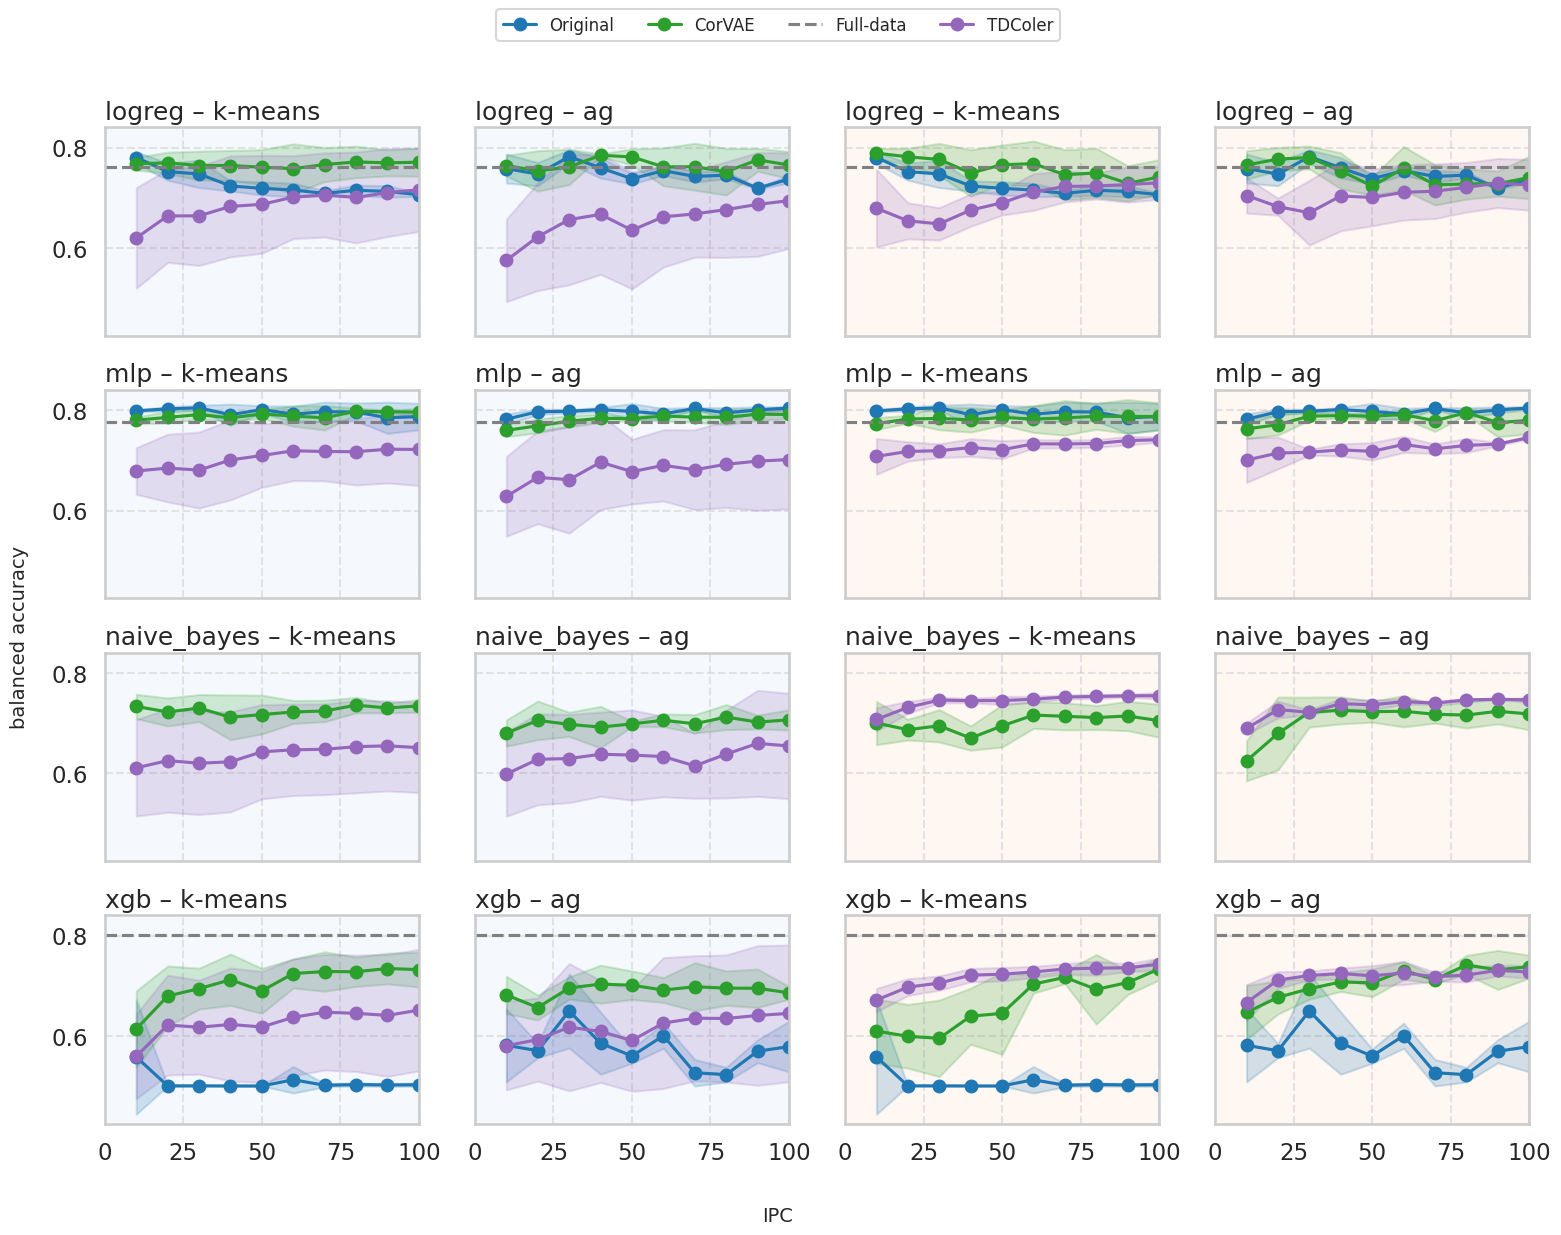

In [9]:
methods = ['k-means','ag']
models = ['logreg','mlp','naive_bayes','xgb']
plot_metric_grid_all(
    df_full=df_full_adult[['model','method','IPC','test_balanced']],
    df_only_coreset=df_only_coreset_adult[['model','method','IPC','test_balanced']],
    df_latent=df_latent_adult[['model','method','IPC','test_balanced','space']],
    df_latent_ft=df_latent_ft_adult[['model','method','IPC','test_balanced','space']],
    df_TDColer=df_tdcoler_latent_adult,
    #space='original',      
    metric='test_balanced',
    methods=methods,
    models=models,
    x_label='IPC',
    y_label='balanced accuracy',
    name_savefig='metrics_figs/adult_tdcoler_kg_test_balanced.png'
)

In [18]:
import pandas as pd

# —————————————————————————————————————————————————————————————————————
# 0) Asume que ya tienes estos DataFrames en tu workspace:
#
#   df_only_coreset_adult      # cols: ['model','method','IPC','test_balanced']
#   df_latent_adult            # cols: ['model','method','IPC','test_balanced','space']
#   df_latent_ft_adult         # cols: ['model','method','IPC','test_balanced','space']
#   df_tdcoler_latent_adult    # cols: ['model','method','IPC','test_balanced','space']
# —————————————————————————————————————————————————————————————————————

# 1) Unificar todas las técnicas en un solo DataFrame
df_list = []

# Only-Coreset (siempre original)
tmp = df_only_coreset_adult.copy()
tmp['technique'] = 'Only-Coreset'
tmp['space']     = 'original'
df_list.append(tmp)

# CorVAE reconstruido (espacio latent)
tmp = df_latent_adult.copy()
tmp['technique'] = 'CorVAE-recon'
df_list.append(tmp)

# CorVAE fine-tuned (espacio latent) – opcional
if not df_latent_ft_adult.empty:
    tmp = df_latent_ft_adult.copy()
    tmp['technique'] = 'CorVAE-latent'
    df_list.append(tmp)

# TDColer (puede haber en original y en latent)
if not df_tdcoler_latent_adult.empty:
    tmp = df_tdcoler_latent_adult.copy()
    tmp['technique'] = 'TDColer'
    df_list.append(tmp)

# Concatenar todo
df_all = pd.concat(df_list, ignore_index=True)

df_all = df_all[df_all['method'] != 'craig']
df_all = df_all[df_all['model'] != 'knn']

# 2) Filtrar solo IPC = 50
df50 = df_all[df_all['IPC'] == 50]

# 3) Agrupar y calcular mean/std de test_balanced
stats = (
    df50
    .groupby(['technique','space','model','method'])['test_balanced']
    .agg(mean='mean', std='std')
    .reset_index()
)

# 4) Formatear media±std
stats['fmt'] = stats.apply(
    lambda row: f"{row['mean']:.3f}±{row['std']:.3f}",
    axis=1
)

# 5) Pivot para que métodos (km, ag, k-center, lc) sean columnas
table = (
    stats
    .pivot_table(
        index=['technique','space','model'],
        columns='method',
        values='fmt',
        aggfunc='first'
    )
    .reset_index()
)

# 6) Renombrar columnas de método a abreviaturas bonitas
table = table.rename(columns={
    'k-means': 'KM',
    'ag':      'AG',
    'k-center':'K-center',
    'lc':      'LC'
})

# 7) (Opcional) Ordenar filas si quieres
table = table.sort_values(['technique','space','model'])

table['technique'] = (table['technique']
        .replace({
            'Only-Coreset': 'Sólo Coreset',
            'CorVAE-recon': 'CorVAE',
            'CorVAE-latent': 'CorVAE',
        })                
        )

table['model'] = (table['model']
        .replace({
            'logreg': 'Regresión Logística',
            'mlp': 'Perceptrón Multicapa',
            'naive_bayes': 'Ingenuo Bayesiano',
            'xgb': 'XGBoost',
            'rf':'Bosque Aleatorio',
            'svm':'Máquina de Vectores de Soporte',
        })                
        )

table['space'] = (table['space']
        .replace({
            'latent': 'Latente',
            'original': 'Reconstruido',
        })                
        )

# 8) Mostrar
table

method,technique,space,model,AG,K-center,KM,LC,random
0,CorVAE,Latente,Regresión Logística,0.761±0.052,0.725±0.021,0.741±0.051,NaN,NaN
1,CorVAE,Latente,Perceptrón Multicapa,0.784±0.023,0.691±0.023,0.790±0.025,NaN,NaN
2,CorVAE,Latente,Ingenuo Bayesiano,0.712±0.020,0.742±0.032,0.696±0.043,NaN,NaN
3,CorVAE,Latente,Bosque Aleatorio,0.710±0.028,0.709±0.030,0.705±0.024,NaN,NaN
4,CorVAE,Latente,svc,0.791±0.012,0.624±0.056,0.765±0.031,NaN,NaN
5,CorVAE,Latente,XGBoost,0.706±0.014,0.669±0.042,0.650±0.073,NaN,NaN
6,CorVAE,Reconstruido,Regresión Logística,0.774±0.029,0.730±0.028,0.771±0.033,NaN,0.780±0.010
7,CorVAE,Reconstruido,Perceptrón Multicapa,0.782±0.019,0.697±0.018,0.785±0.020,NaN,0.776±0.009
8,CorVAE,Reconstruido,Ingenuo Bayesiano,0.727±0.028,0.574±0.043,0.729±0.031,NaN,0.670±0.053
9,CorVAE,Reconstruido,Bosque Aleatorio,0.747±0.019,0.729±0.039,0.746±0.034,NaN,0.774±0.006


KeyError: 'Level [0, 1] not found'

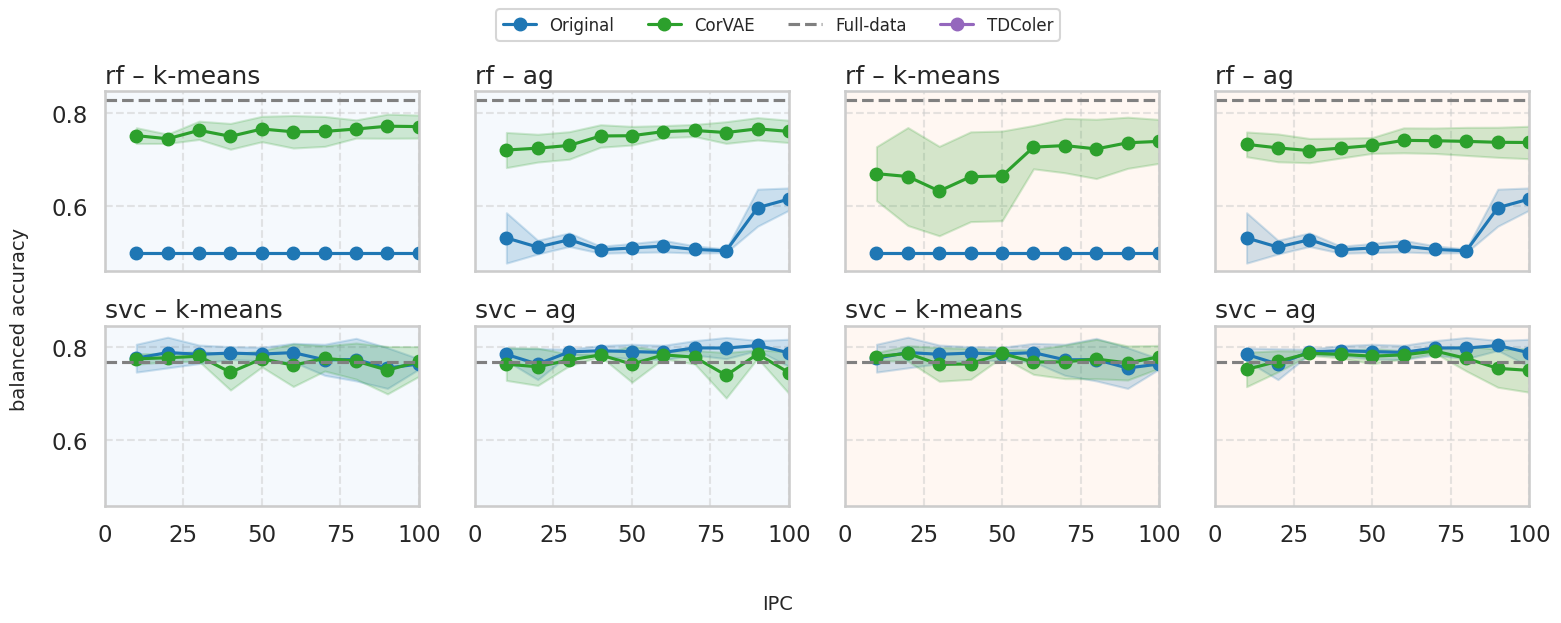

In [10]:
methods = ['k-means','ag']
models = ['rf','svc']
plot_metric_grid_all(
    df_full=df_full_adult[['model','method','IPC','test_balanced']],
    df_only_coreset=df_only_coreset_adult[['model','method','IPC','test_balanced']],
    df_latent=df_latent_adult[['model','method','IPC','test_balanced','space']],
    df_latent_ft=df_latent_ft_adult[['model','method','IPC','test_balanced','space']],
    df_TDColer=df_tdcoler_latent_adult,
    #space='original',      
    metric='test_balanced',
    methods=methods,
    models=models,
    x_label='IPC',
    y_label='balanced accuracy',
    name_savefig='metrics_figs/adult_kg_test_balanced.png'
)

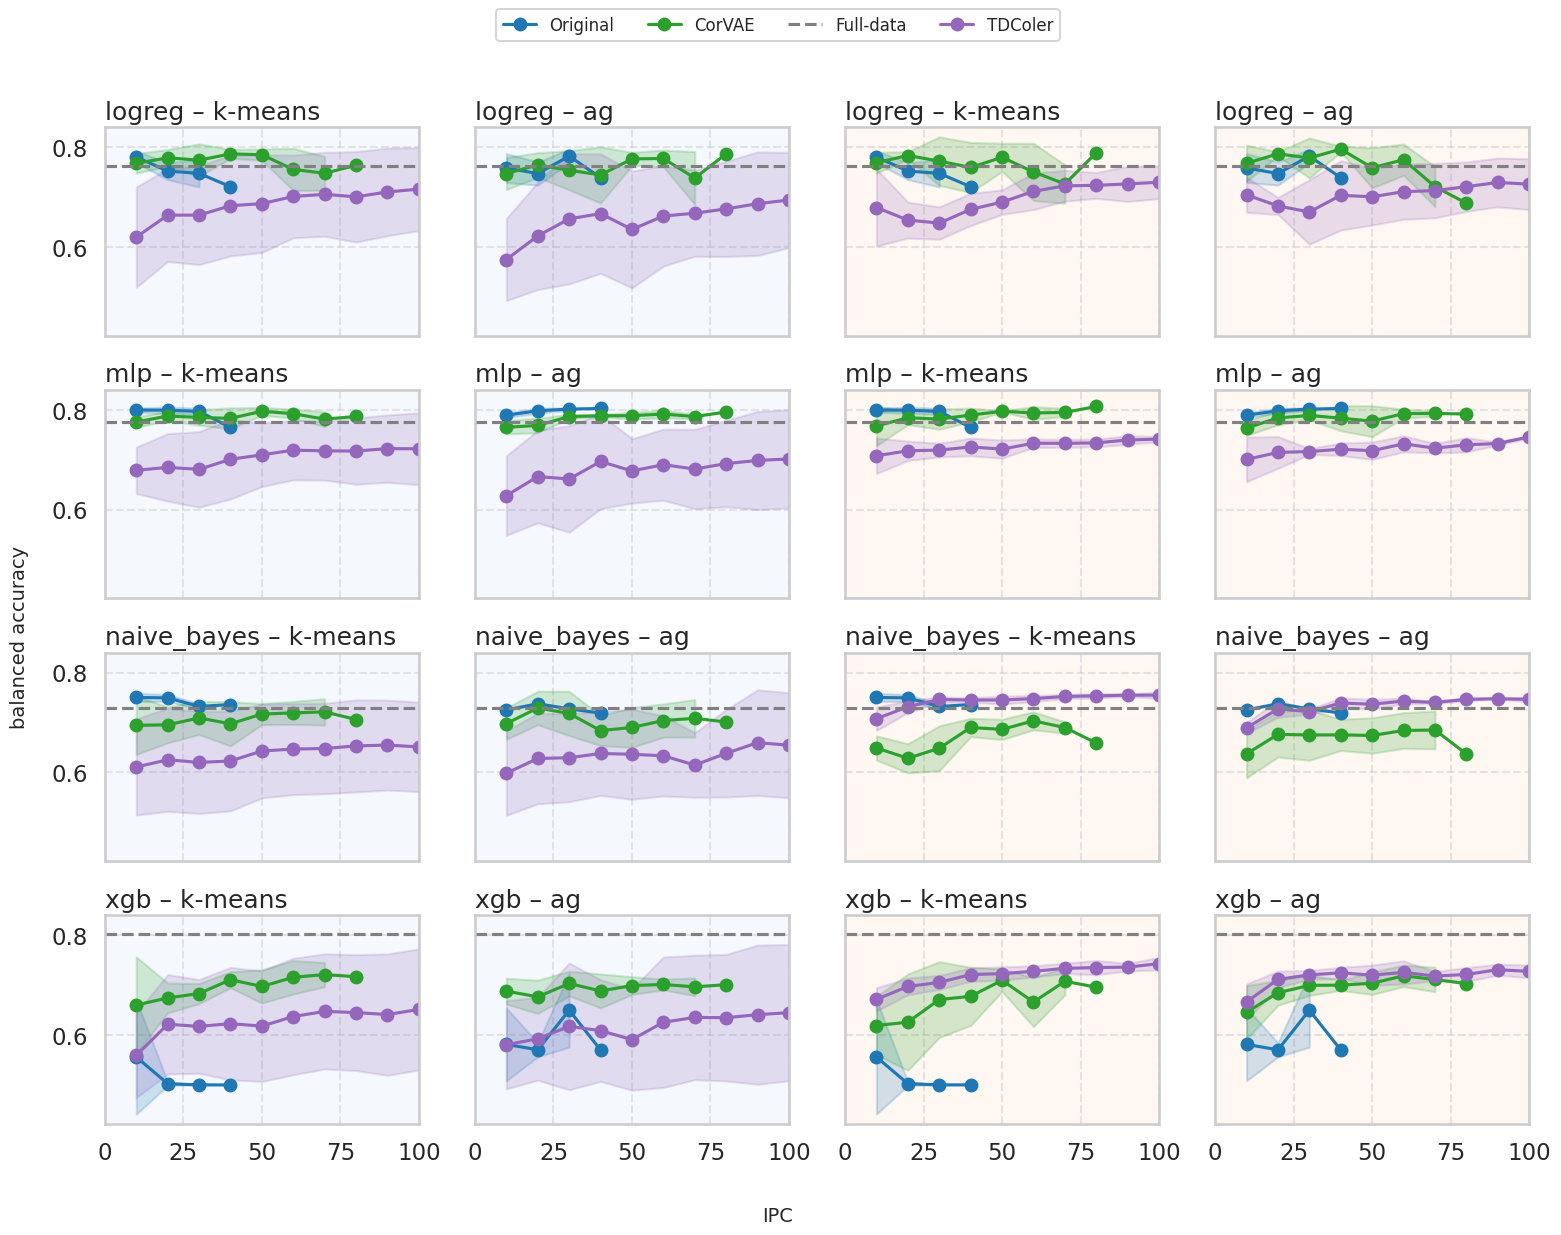

In [38]:
methods = ['k-means','ag']
models = ['logreg','mlp','naive_bayes','xgb']
plot_metric_grid_all(
    df_full=df_full_adult[['model','method','IPC','test_balanced']],
    df_only_coreset=df_only_coreset_adult[['model','method','IPC','test_balanced']],
    df_latent=df_latent_adult[['model','method','IPC','test_balanced','space']],
    df_latent_ft=df_latent_ft_adult[['model','method','IPC','test_balanced','space']],
    df_TDColer=df_tdcoler_latent_adult,
    #space='original',      
    metric='test_balanced',
    methods=methods,
    models=models,
    x_label='IPC',
    y_label='balanced accuracy',
    name_savefig='metrics_figs/adult_tdcoler_original_kg_test_balanced.png'
)

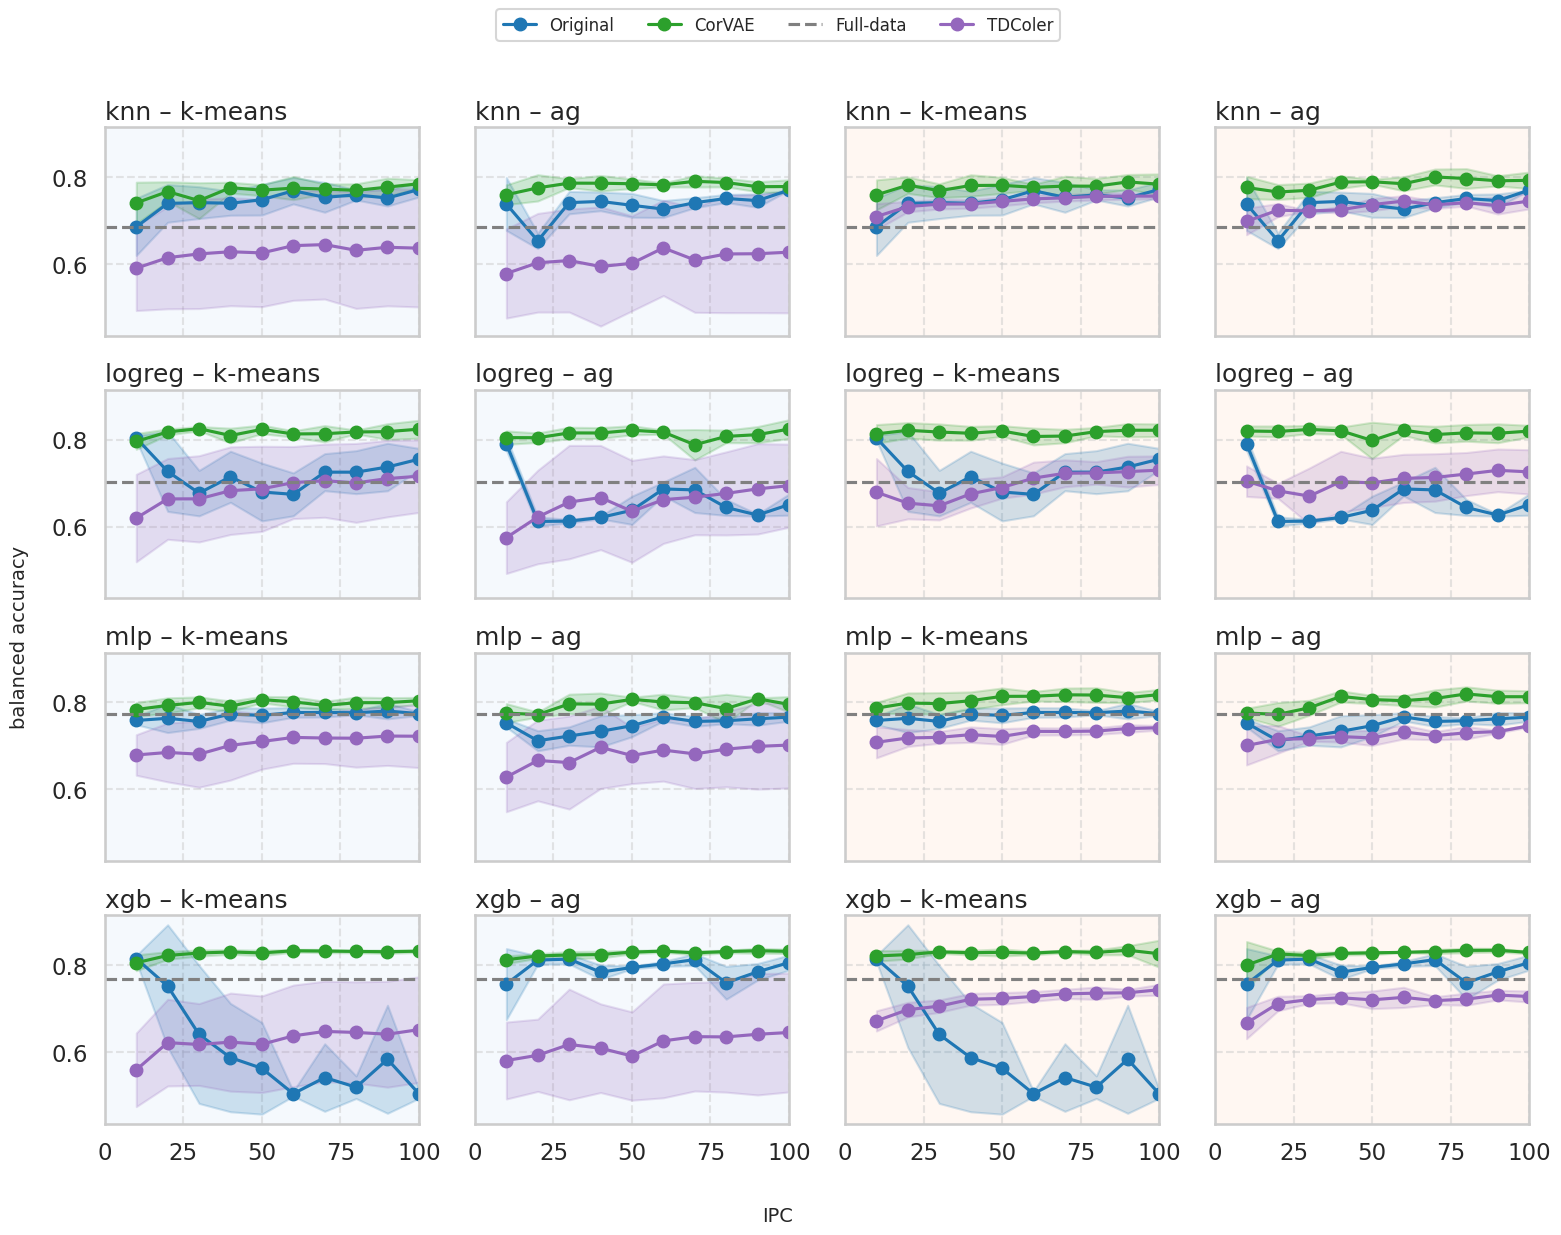

In [ ]:
methods = ['k-means','ag']
models = ['logreg','mlp','naive_bayes','xgb']
plot_metric_grid_all(
    df_full=df_full_adult[['model','method','IPC','test_balanced']],
    df_only_coreset=df_only_coreset_adult[['model','method','IPC','test_balanced']],
    df_latent=df_latent_adult[['model','method','IPC','test_balanced','space']],
    df_latent_ft=df_latent_ft_adult[['model','method','IPC','test_balanced','space']],
    df_TDColer=df_tdcoler_latent_adult,
    #space='original',      
    metric='test_balanced',
    methods=methods,
    models=models,
    x_label='IPC',
    y_label='balanced accuracy',
    name_savefig='metrics_figs/adult_tdcoler_original_kg_test_balanced.png'
)

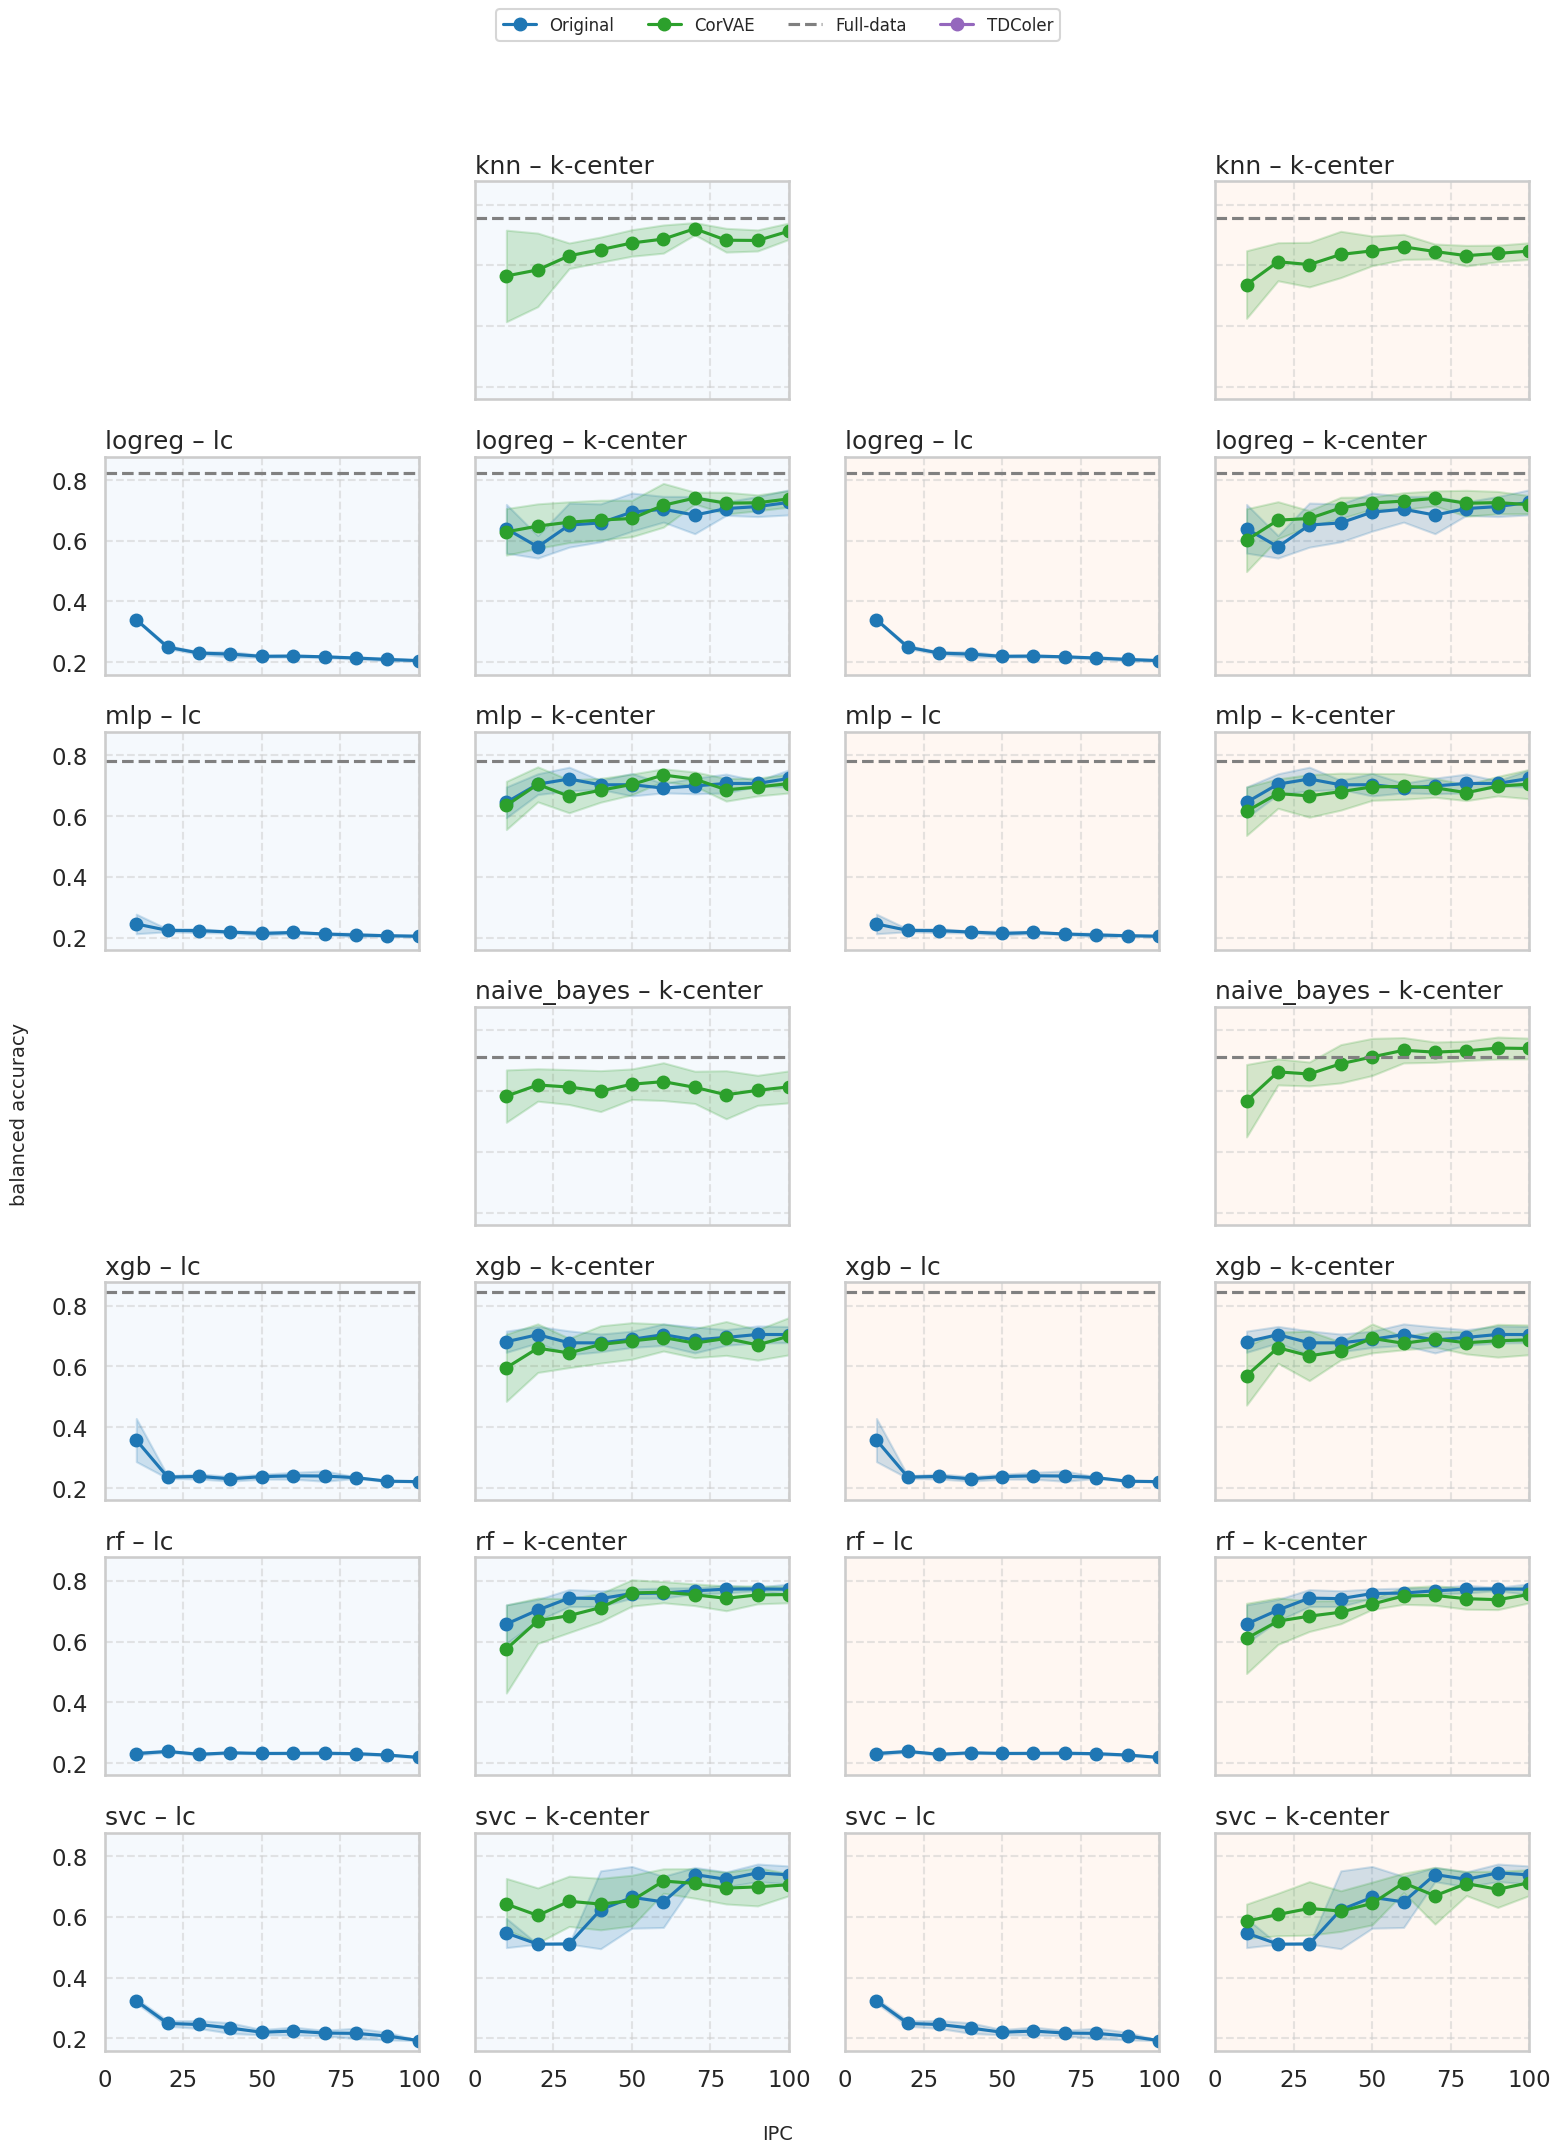

In [11]:
methods = ['lc','k-center']
models = ['knn','logreg','mlp','naive_bayes','xgb','rf','svc']
plot_metric_grid_all(
    df_full=df_tdcoler_full_adult,
    df_only_coreset=df_only_coreset_adult[['model','method','IPC','test_balanced']],
    df_latent=df_latent_adult[['model','method','IPC','test_balanced','space']],
    df_latent_ft=df_latent_ft_adult[['model','method','IPC','test_balanced','space']],
    df_TDColer=df_tdcoler_latent_adult,
    #space='original',      
    metric='test_balanced',
    methods=methods,
    models=models,
    x_label='IPC',
    y_label='balanced accuracy',
    name_savefig='metrics_figs/adult_lck_test_balanced.png'
)

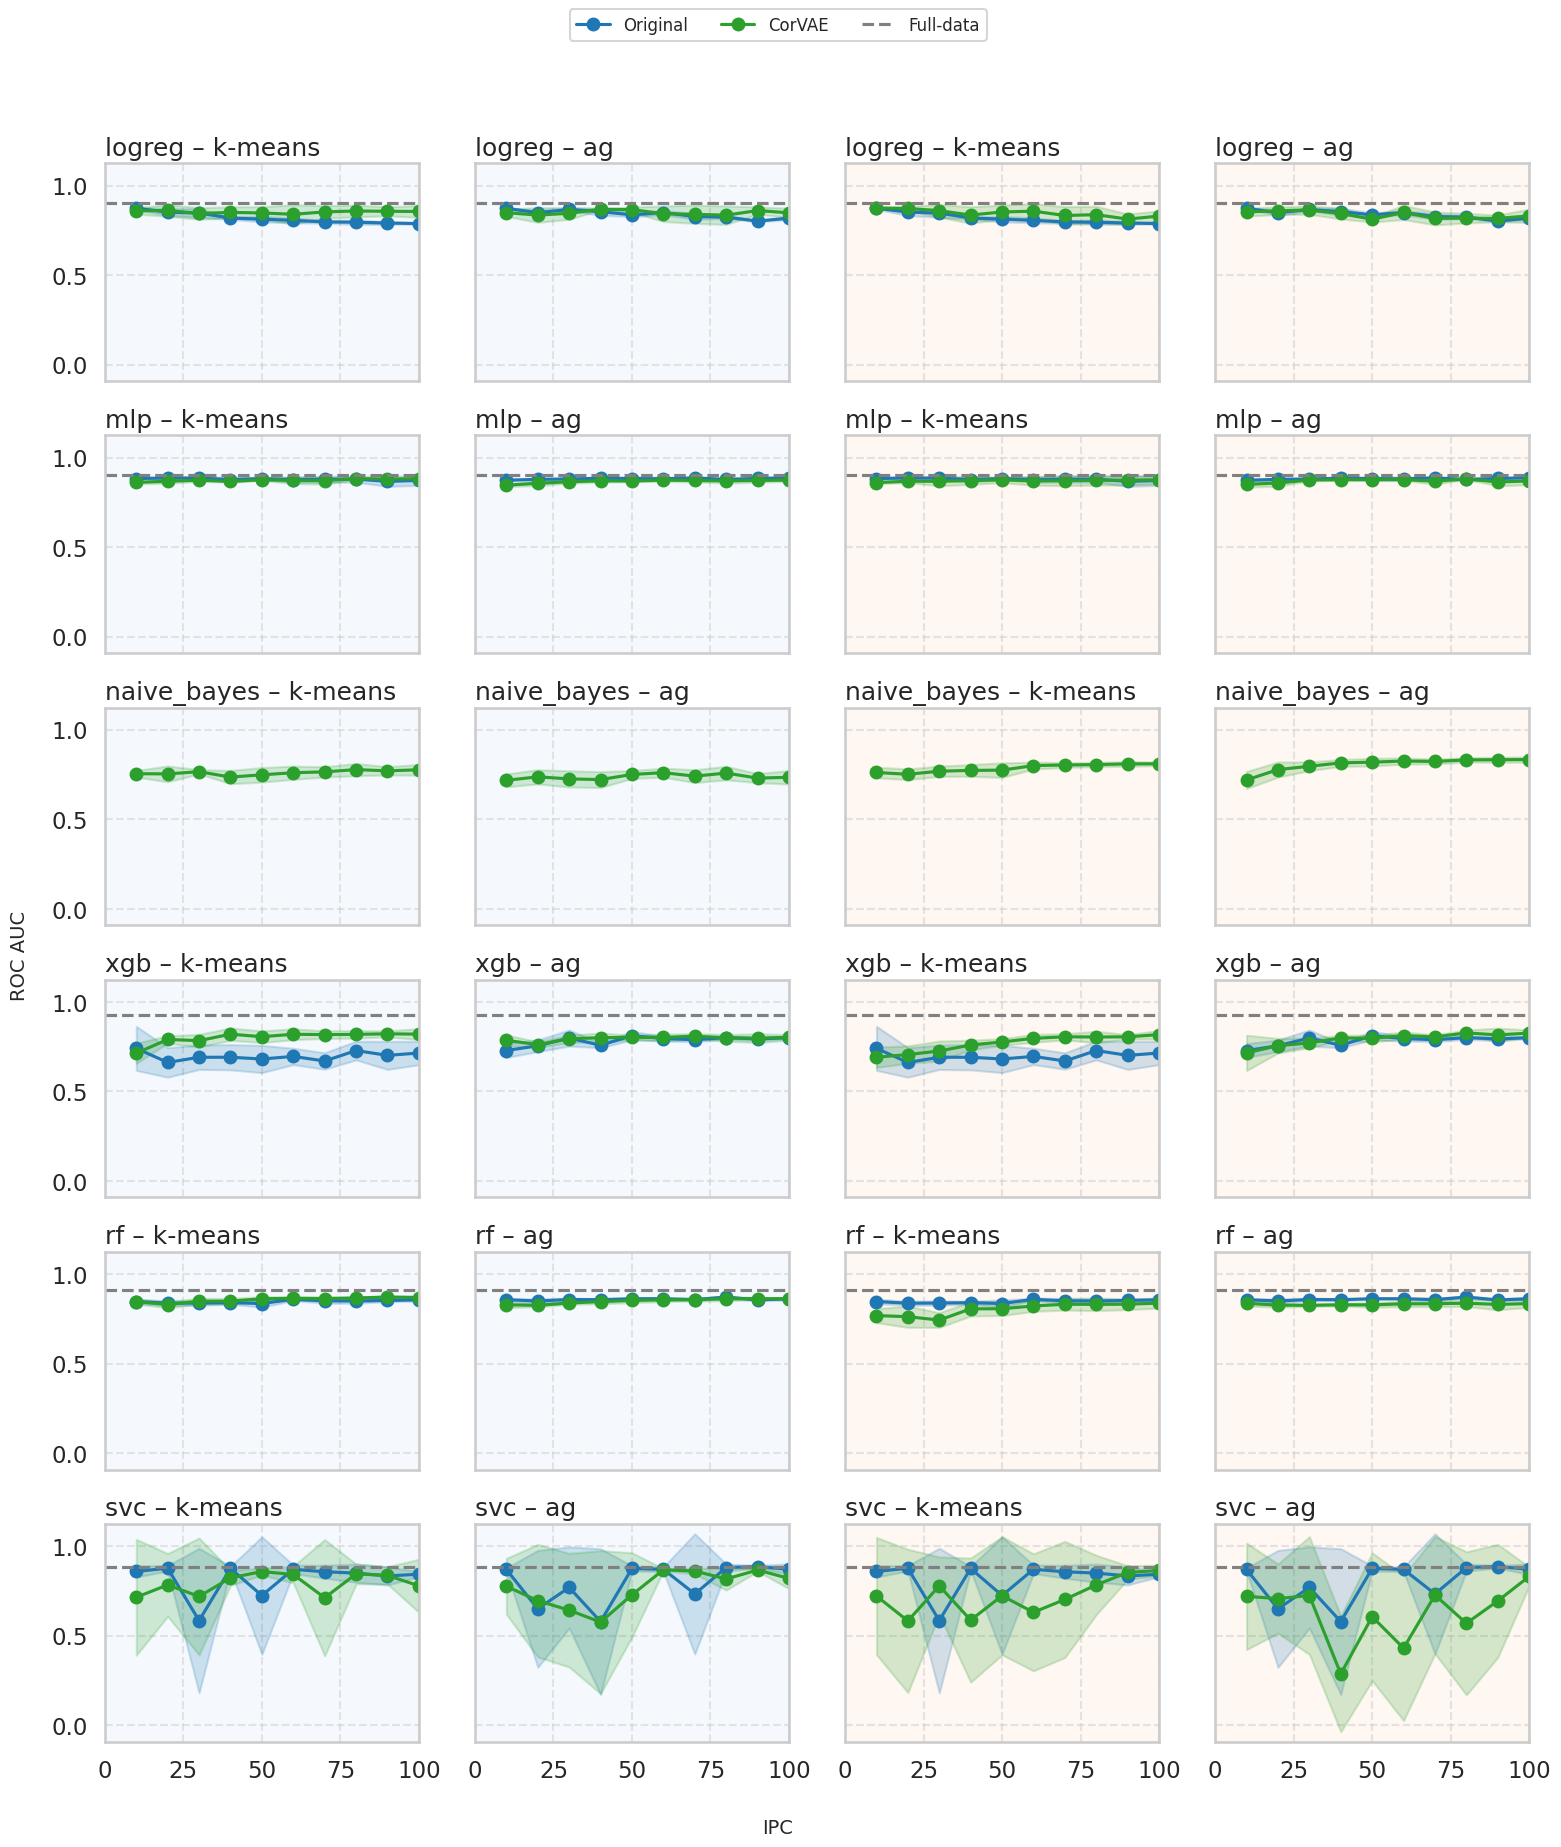

In [12]:
methods = ['k-means','ag']
models = ['logreg','mlp','naive_bayes','xgb','rf','svc']
plot_metric_grid_all(
    df_full=df_full_adult[['model','method','IPC','test_roc_auc']],
    df_only_coreset=df_only_coreset_adult[['model','method','IPC','test_roc_auc']],
    df_latent=df_latent_adult[['model','method','IPC','test_roc_auc','space']],
    df_latent_ft=df_latent_ft_adult[['model','method','IPC','test_roc_auc','space']],
    #df_TDColer=df_tdcoler_latent_adult,
    #space='original',      
    metric='test_roc_auc',
    methods=methods,
    models=models,
    x_label='IPC',
    y_label='ROC AUC',
    name_savefig='metrics_figs/adult_kg_roc_auc.png'
)

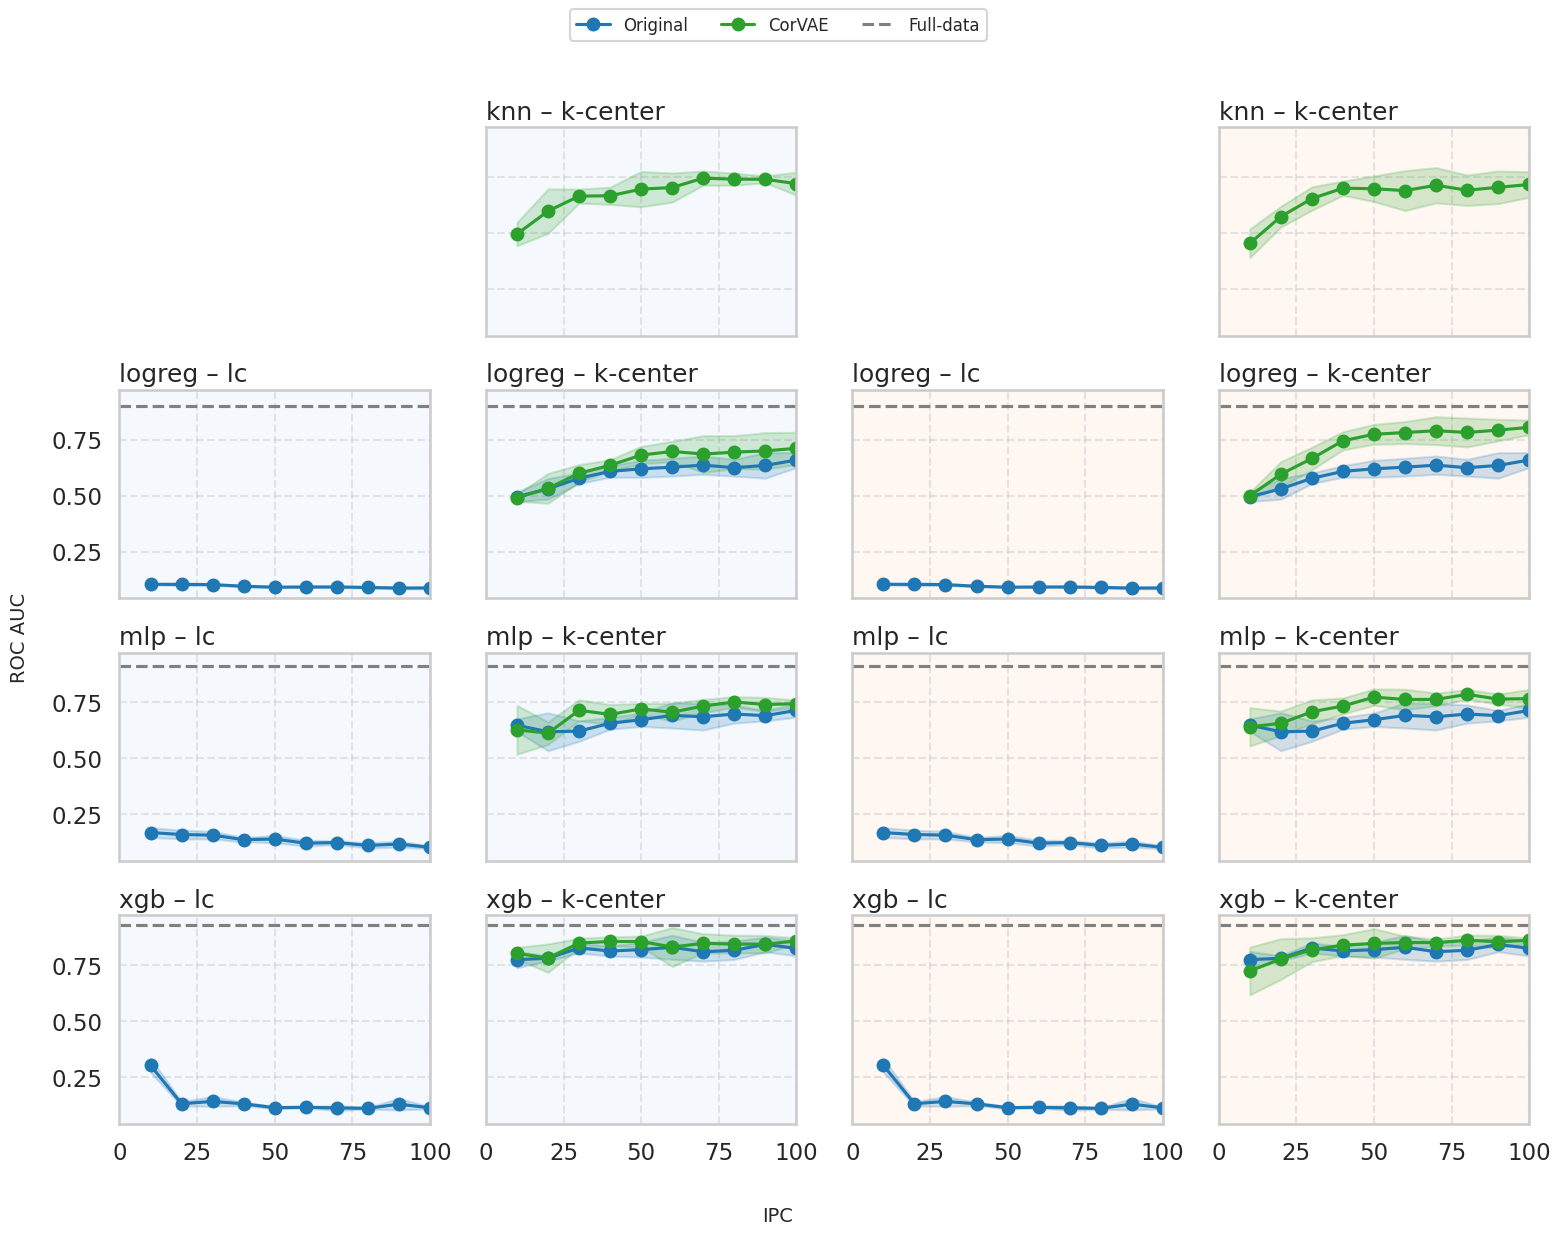

In [123]:
methods = ['lc','k-center']
models = ['knn','logreg','mlp','xgb']
plot_metric_grid_all(
    df_full=df_full_adult[['model','method','IPC','test_roc_auc']],
    df_only_coreset=df_only_coreset_adult[['model','method','IPC','test_roc_auc']],
    df_latent=df_latent_adult[['model','method','IPC','test_roc_auc','space']],
    df_latent_ft=df_latent_ft_adult[['model','method','IPC','test_roc_auc','space']],
    #df_TDColer=df_tdcoler_latent_adult,
    #space='original',      
    metric='test_roc_auc',
    methods=methods,
    models=models,
    x_label='IPC',
    y_label='ROC AUC',
    name_savefig='metrics_figs/adult_tdcoler_original_lck_roc_auc.png'
)

## Dataset Default

In [23]:
df_only_coreset_default = pd.read_csv('Experiments_N/checkpoint_default_Doriginal_H/metrics.csv')
df_only_coreset_default['method'] = df_only_coreset_default['method'].replace(
     'k_center', 'k-center'
)
df_full_default = df_only_coreset_adult[df_only_coreset_adult['method'] == 'Full-data']
df_latent_default = pd.read_csv('Experiments_N/checkpoint_default_Dlatent_G/metrics.csv')
df_latent_ft_default = pd.read_csv('Experiments_N/checkpoint_default_Dlatent_ft_H/metrics.csv')

### Tablas

In [45]:
df_full_default[['model','method','test_balanced','test_roc_auc']]

,model,method,test_balanced,test_roc_auc
0,xgb,Full-data,0.802,0.927
1,rf,Full-data,0.829,0.912
2,svc,Full-data,0.768,0.883
3,logreg,Full-data,0.762,0.902
4,mlp,Full-data,0.776,0.903


In [33]:
def summarize_two_metrics(
    ipc: float,
    df_only_coreset: pd.DataFrame,
    df_latent: pd.DataFrame,
    df_tdcoler: pd.DataFrame,
    df_latent_ft: pd.DataFrame = None
) -> pd.DataFrame:
    """
    Construye una tabla resumen con las métricas test_balanced y test_roc_auc,
    filtrando por un valor específico de IPC y combinando varias técnicas.

    La salida es un DataFrame con índices (technique, space, model) y
    columnas multiíndice donde el primer nivel es la métrica
    (test_balanced a la izquierda, test_roc_auc a la derecha) y
    el segundo nivel los métodos ('KM','AG','K-center','LC').
    """
    # 0) Combinar DataFrames de las técnicas
    df_list = []
    # Only-Coreset (original)
    tmp = df_only_coreset.copy()
    tmp['technique'] = 'Only-Coreset'
    tmp['space']     = 'original'
    df_list.append(tmp)
    # CorVAE reconstruido
    tmp = df_latent.copy()
    tmp['technique'] = 'CorVAE-recon'
    df_list.append(tmp)
    # CorVAE fine-tuned (opcional)
    if df_latent_ft is not None and not df_latent_ft.empty:
        tmp = df_latent_ft.copy()
        tmp['technique'] = 'CorVAE-latent'
        df_list.append(tmp)
    # TDColer
    if not df_tdcoler.empty:
        tmp = df_tdcoler.copy()
        tmp['technique'] = 'TDColer'
        df_list.append(tmp)
    df_all = pd.concat(df_list, ignore_index=True)
    # Filtrar métodos y modelos no deseados
    df_all = df_all[~df_all['method'].isin(['craig', 'random'])]
    df_all = df_all[df_all['model'] != 'knn']
    # Filtrar por IPC
    df_ipc = df_all[df_all['IPC'] == ipc]

    # Función auxiliar para pivotar una métrica
    def pivot_metric(df: pd.DataFrame, metric: str) -> pd.DataFrame:
        stats = (
            df
            .groupby(['technique','space','model','method'])[metric]
            .agg(mean='mean', std='std')
            .reset_index()
        )
        stats['fmt'] = stats.apply(
            lambda r: f"{r['mean']:.3f}±{r['std']:.3f}", axis=1
        )
        table = (
            stats
            .pivot_table(
                index=['technique','space','model'],
                columns='method',
                values='fmt',
                aggfunc='first'
            )
        )
        return table.rename(columns={
            'k-means':  'KM',
            'ag':       'AG',
            'k-center': 'K-center',
            'lc':       'LC'
        })

    # 1) Pivot para cada métrica
    table_bal = pivot_metric(df_ipc, 'test_balanced')
    table_roc = pivot_metric(df_ipc, 'test_roc_auc')
    # 2) Concatenar lado a lado con multiíndice en columnas
    combined = pd.concat(
        [table_bal, table_roc],
        axis=1,
        keys=['test_balanced', 'test_roc_auc']
    )
    # 3) Reset del índice para obtener columnas planas de técnica, espacio y modelo
    combined = combined.reset_index()
    # 4) Traducir etiquetas
    combined['technique'] = combined['technique'].replace({
        'Only-Coreset':   'Sólo Coreset',
        'CorVAE-recon':   'CorVAE',
        'CorVAE-latent':  'CorVAE',
        'TDColer':        'TDColer'
    })
    combined['model'] = combined['model'].replace({
        'logreg':       'Regresión Logística',
        'mlp':          'Perceptrón Multicapa',
        'naive_bayes': 'Ingenuo Bayesiano',
        'xgb':          'XGBoost',
        'rf':           'Bosque Aleatorio',
        'svm':          'Máquina de Vectores de Soporte'
    })
    combined['space'] = combined['space'].replace({
        'latent':     'Latente',
        'original':  'Reconstruido'
    })

    return combined


In [34]:
tabla = summarize_two_metrics(
    ipc=10,
    #metric='test_balanced',
    df_only_coreset=df_only_coreset_default,
    df_latent=df_latent_default,
    df_tdcoler=df_tdcoler_latent_default,
    df_latent_ft=None
)
tabla

technique         space                 model test_balanced  \
method                                                              AG   
0             CorVAE       Latente   Regresión Logística   0.637±0.037   
1             CorVAE       Latente  Perceptrón Multicapa   0.650±0.016   
2             CorVAE       Latente     Ingenuo Bayesiano   0.525±0.013   
3             CorVAE       Latente      Bosque Aleatorio   0.663±0.021   
4             CorVAE       Latente                   svc   0.655±0.028   
5             CorVAE       Latente               XGBoost   0.637±0.026   
6             CorVAE  Reconstruido   Regresión Logística   0.618±0.046   
7             CorVAE  Reconstruido  Perceptrón Multicapa   0.635±0.017   
8             CorVAE  Reconstruido     Ingenuo Bayesiano   0.650±0.033   
9             CorVAE  Reconstruido      Bosque Aleatorio   0.592±0.023   
10            CorVAE  Reconstruido                   svc   0.625±0.042   
11            CorVAE  Reconstruido               XGBoost   0.583±0.011   
12      Sólo Coreset  Reconstruido   Regresión Logística   0.660±0.014   
13      Sólo Coreset  Reconstruido  Perceptrón Multicapa   0.674±0.005   
14      Sólo Coreset  Reconstruido     Ingenuo Bayesiano   0.620±0.007   
15      Sólo Coreset  Reconstruido      Bosque Aleatorio   0.637±0.028   
16      Sólo Coreset  Reconstruido                   svc   0.503±0.005   
17      Sólo Coreset  Reconstruido               XGBoost   0.537±0.062   
18           TDColer       Latente   Regresión Logística   0.672±0.014   
19           TDColer       Latente  Perceptrón Multicapa   0.665±0.024   
20           TDColer       Latente     Ingenuo Bayesiano   0.625±0.027   
21           TDColer       Latente               XGBoost   0.591±0.037   
22           TDColer  Reconstruido   Regresión Logística   0.647±0.017   
23           TDColer  Reconstruido  Perceptrón Multicapa   0.651±0.017   
24           TDColer  Reconstruido     Ingenuo Bayesiano   0.630±0.053   
25           TDColer  Reconstruido               XGBoost   0.594±0.050   

                                              test_roc_auc               \
method     K-center           KM           LC           AG     K-center   
0       0.501±0.001  0.624±0.019  0.334±0.032  0.689±0.050  0.561±0.049   
1       0.516±0.032  0.664±0.016  0.345±0.030  0.712±0.021  0.544±0.050   
2       0.502±0.014  0.561±0.053  0.408±0.014  0.613±0.028  0.513±0.028   
3       0.505±0.004  0.643±0.026  0.365±0.050  0.720±0.022  0.476±0.068   
4       0.500±0.000  0.652±0.039  0.344±0.028  0.365±0.124  0.528±0.057   
5       0.496±0.042  0.622±0.025  0.420±0.013  0.693±0.017  0.477±0.087   
6       0.500±0.000  0.607±0.026  0.415±0.048  0.673±0.062  0.594±0.037   
7       0.514±0.033  0.645±0.020  0.329±0.020  0.699±0.024  0.516±0.058   
8       0.610±0.071  0.663±0.025  0.385±0.004  0.661±0.035  0.585±0.076   
9       0.538±0.019  0.585±0.016  0.395±0.016  0.644±0.030  0.552±0.059   
10      0.500±0.000  0.618±0.029  0.410±0.019  0.432±0.183  0.515±0.064   
11      0.544±0.019  0.576±0.016  0.442±0.043  0.618±0.014  0.566±0.049   
12      0.500±0.000  0.668±0.023  0.487±0.001  0.733±0.021  0.572±0.008   
13      0.513±0.022  0.677±0.014  0.385±0.040  0.747±0.005  0.513±0.027   
14      0.548±0.083  0.690±0.011  0.382±0.000  0.656±0.007  0.581±0.071   
15      0.489±0.017  0.533±0.075  0.371±0.013  0.728±0.021  0.485±0.014   
16      0.500±0.000  0.545±0.067  0.487±0.003  0.399±0.064  0.522±0.044   
17      0.503±0.026  0.517±0.027  0.435±0.006  0.660±0.065  0.522±0.058   
18              NaN  0.654±0.030          NaN      nan±nan          NaN   
19              NaN  0.651±0.041          NaN      nan±nan          NaN   
20              NaN  0.604±0.025          NaN      nan±nan          NaN   
21              NaN  0.594±0.028          NaN      nan±nan          NaN   
22              NaN  0.627±0.030          NaN      nan±nan          NaN   
23              NaN  0.625±0.030          NaN      nan±nan     

In [35]:
tabla = summarize_two_metrics(
    ipc=50,
    #metric='test_balanced',
    df_only_coreset=df_only_coreset_default,
    df_latent=df_latent_default,
    df_tdcoler=df_tdcoler_latent_default,
    df_latent_ft=None
)
tabla

technique         space                 model test_balanced  \
method                                                              AG   
0             CorVAE       Latente   Regresión Logística   0.673±0.040   
1             CorVAE       Latente  Perceptrón Multicapa   0.674±0.012   
2             CorVAE       Latente     Ingenuo Bayesiano   0.578±0.016   
3             CorVAE       Latente      Bosque Aleatorio   0.655±0.014   
4             CorVAE       Latente                   svc   0.669±0.015   
5             CorVAE       Latente               XGBoost   0.648±0.011   
6             CorVAE  Reconstruido   Regresión Logística   0.633±0.030   
7             CorVAE  Reconstruido  Perceptrón Multicapa   0.667±0.008   
8             CorVAE  Reconstruido     Ingenuo Bayesiano   0.601±0.052   
9             CorVAE  Reconstruido      Bosque Aleatorio   0.620±0.011   
10            CorVAE  Reconstruido                   svc   0.656±0.008   
11            CorVAE  Reconstruido               XGBoost   0.591±0.017   
12      Sólo Coreset  Reconstruido   Regresión Logística   0.610±0.002   
13      Sólo Coreset  Reconstruido  Perceptrón Multicapa   0.681±0.007   
14      Sólo Coreset  Reconstruido     Ingenuo Bayesiano   0.683±0.001   
15      Sólo Coreset  Reconstruido      Bosque Aleatorio   0.553±0.016   
16      Sólo Coreset  Reconstruido                   svc   0.562±0.086   
17      Sólo Coreset  Reconstruido               XGBoost   0.531±0.025   
18           TDColer       Latente   Regresión Logística   0.677±0.006   
19           TDColer       Latente  Perceptrón Multicapa   0.665±0.015   
20           TDColer       Latente     Ingenuo Bayesiano   0.658±0.022   
21           TDColer       Latente               XGBoost   0.619±0.024   
22           TDColer  Reconstruido   Regresión Logística   0.640±0.012   
23           TDColer  Reconstruido  Perceptrón Multicapa   0.620±0.038   
24           TDColer  Reconstruido     Ingenuo Bayesiano   0.610±0.029   
25           TDColer  Reconstruido               XGBoost   0.606±0.014   

                                              test_roc_auc               \
method     K-center           KM           LC           AG     K-center   
0       0.506±0.001  0.625±0.033  0.351±0.013  0.731±0.049  0.645±0.019   
1       0.508±0.013  0.691±0.007  0.345±0.006  0.740±0.010  0.574±0.074   
2       0.503±0.001  0.602±0.032  0.371±0.031  0.628±0.035  0.519±0.013   
3       0.515±0.011  0.650±0.024  0.345±0.011  0.725±0.017  0.610±0.100   
4       0.503±0.002  0.673±0.015  0.361±0.011  0.748±0.012  0.498±0.138   
5       0.525±0.028  0.657±0.035  0.356±0.043  0.713±0.016  0.528±0.076   
6       0.503±0.001  0.647±0.052  0.335±0.008  0.689±0.046  0.606±0.050   
7       0.513±0.014  0.675±0.008  0.346±0.006  0.731±0.010  0.628±0.031   
8       0.538±0.037  0.602±0.073  0.369±0.011  0.702±0.007  0.662±0.016   
9       0.526±0.011  0.626±0.017  0.330±0.013  0.672±0.014  0.648±0.051   
10      0.502±0.001  0.669±0.009  0.345±0.006  0.552±0.233  0.513±0.094   
11      0.517±0.036  0.609±0.019  0.334±0.011  0.639±0.024  0.546±0.074   
12      0.504±0.001  0.621±0.014  0.340±0.003  0.628±0.008  0.574±0.052   
13      0.503±0.001  0.694±0.009  0.349±0.006  0.756±0.009  0.490±0.049   
14      0.549±0.072  0.682±0.003  0.384±0.001  0.725±0.000  0.615±0.068   
15      0.503±0.005  0.552±0.035  0.360±0.005  0.756±0.008  0.554±0.031   
16      0.502±0.001  0.630±0.044  0.360±0.005  0.399±0.184  0.573±0.068   
17      0.502±0.010  0.540±0.031  0.359±0.004  0.669±0.012  0.510±0.033   
18              NaN  0.665±0.019          NaN      nan±nan          NaN   
19              NaN  0.657±0.022          NaN      nan±nan          NaN   
20              NaN  0.658±0.018          NaN      nan±nan          NaN   
21              NaN  0.623±0.025          NaN      nan±nan          NaN   
22              NaN  0.624±0.025          NaN      nan±nan          NaN   
23              NaN  0.618±0.026          NaN      nan±nan     

In [36]:
tabla = summarize_two_metrics(
    ipc=100,
    #metric='test_balanced',
    df_only_coreset=df_only_coreset_default,
    df_latent=df_latent_default,
    df_tdcoler=df_tdcoler_latent_default,
    df_latent_ft=None
)
tabla

technique         space                 model test_balanced  \
method                                                              AG   
0             CorVAE       Latente   Regresión Logística   0.646±0.040   
1             CorVAE       Latente  Perceptrón Multicapa   0.683±0.009   
2             CorVAE       Latente     Ingenuo Bayesiano   0.544±0.009   
3             CorVAE       Latente      Bosque Aleatorio   0.649±0.013   
4             CorVAE       Latente                   svc   0.673±0.015   
5             CorVAE       Latente               XGBoost   0.641±0.019   
6             CorVAE  Reconstruido   Regresión Logística   0.659±0.004   
7             CorVAE  Reconstruido  Perceptrón Multicapa   0.675±0.005   
8             CorVAE  Reconstruido     Ingenuo Bayesiano   0.528±0.008   
9             CorVAE  Reconstruido      Bosque Aleatorio   0.621±0.007   
10            CorVAE  Reconstruido                   svc   0.671±0.004   
11            CorVAE  Reconstruido               XGBoost   0.584±0.012   
12      Sólo Coreset  Reconstruido   Regresión Logística   0.637±0.011   
13      Sólo Coreset  Reconstruido  Perceptrón Multicapa   0.683±0.005   
14      Sólo Coreset  Reconstruido     Ingenuo Bayesiano   0.670±0.001   
15      Sólo Coreset  Reconstruido      Bosque Aleatorio   0.607±0.014   
16      Sólo Coreset  Reconstruido                   svc   0.633±0.042   
17      Sólo Coreset  Reconstruido               XGBoost   0.609±0.021   
18           TDColer       Latente   Regresión Logística   0.675±0.011   
19           TDColer       Latente  Perceptrón Multicapa   0.671±0.011   
20           TDColer       Latente     Ingenuo Bayesiano   0.668±0.006   
21           TDColer       Latente               XGBoost   0.646±0.008   
22           TDColer  Reconstruido   Regresión Logística   0.632±0.040   
23           TDColer  Reconstruido  Perceptrón Multicapa   0.636±0.021   
24           TDColer  Reconstruido     Ingenuo Bayesiano   0.576±0.063   
25           TDColer  Reconstruido               XGBoost   0.629±0.015   

                                              test_roc_auc               \
method     K-center           KM           LC           AG     K-center   
0       0.510±0.003  0.647±0.042  0.356±0.010  0.700±0.048  0.677±0.019   
1       0.510±0.005  0.691±0.010  0.346±0.003  0.751±0.009  0.586±0.036   
2       0.505±0.001  0.541±0.006  0.348±0.032  0.616±0.050  0.518±0.008   
3       0.519±0.006  0.643±0.015  0.338±0.013  0.729±0.021  0.648±0.028   
4       0.506±0.002  0.670±0.013  0.353±0.012  0.757±0.008  0.559±0.133   
5       0.517±0.018  0.637±0.009  0.355±0.026  0.709±0.011  0.552±0.042   
6       0.506±0.001  0.657±0.027  0.341±0.005  0.720±0.008  0.642±0.035   
7       0.509±0.003  0.689±0.008  0.348±0.004  0.740±0.010  0.637±0.047   
8       0.537±0.043  0.607±0.067  0.358±0.028  0.711±0.007  0.694±0.011   
9       0.533±0.007  0.629±0.006  0.335±0.005  0.693±0.011  0.676±0.029   
10      0.503±0.001  0.679±0.002  0.347±0.003  0.725±0.007  0.465±0.097   
11      0.523±0.013  0.613±0.005  0.335±0.015  0.645±0.011  0.587±0.045   
12      0.503±0.001  0.628±0.012  0.357±0.003  0.685±0.033  0.659±0.015   
13      0.505±0.000  0.699±0.004  0.361±0.009  0.761±0.004  0.646±0.049   
14      0.537±0.023  0.669±0.006  0.412±0.000  0.722±0.000  0.695±0.003   
15      0.512±0.003  0.525±0.030  0.368±0.007  0.749±0.005  0.665±0.016   
16      0.504±0.002  0.662±0.041  0.363±0.003  0.739±0.007  0.654±0.010   
17      0.516±0.005  0.526±0.015  0.350±0.003  0.710±0.006  0.595±0.025   
18              NaN  0.677±0.013          NaN      nan±nan          NaN   
19              NaN  0.678±0.014          NaN      nan±nan          NaN   
20              NaN  0.670±0.007          NaN      nan±nan          NaN   
21              NaN  0.642±0.012          NaN      nan±nan          NaN   
22              NaN  0.630±0.028          NaN      nan±nan          NaN   
23              NaN  0.634±0.027          NaN      nan±nan     

### Figuras

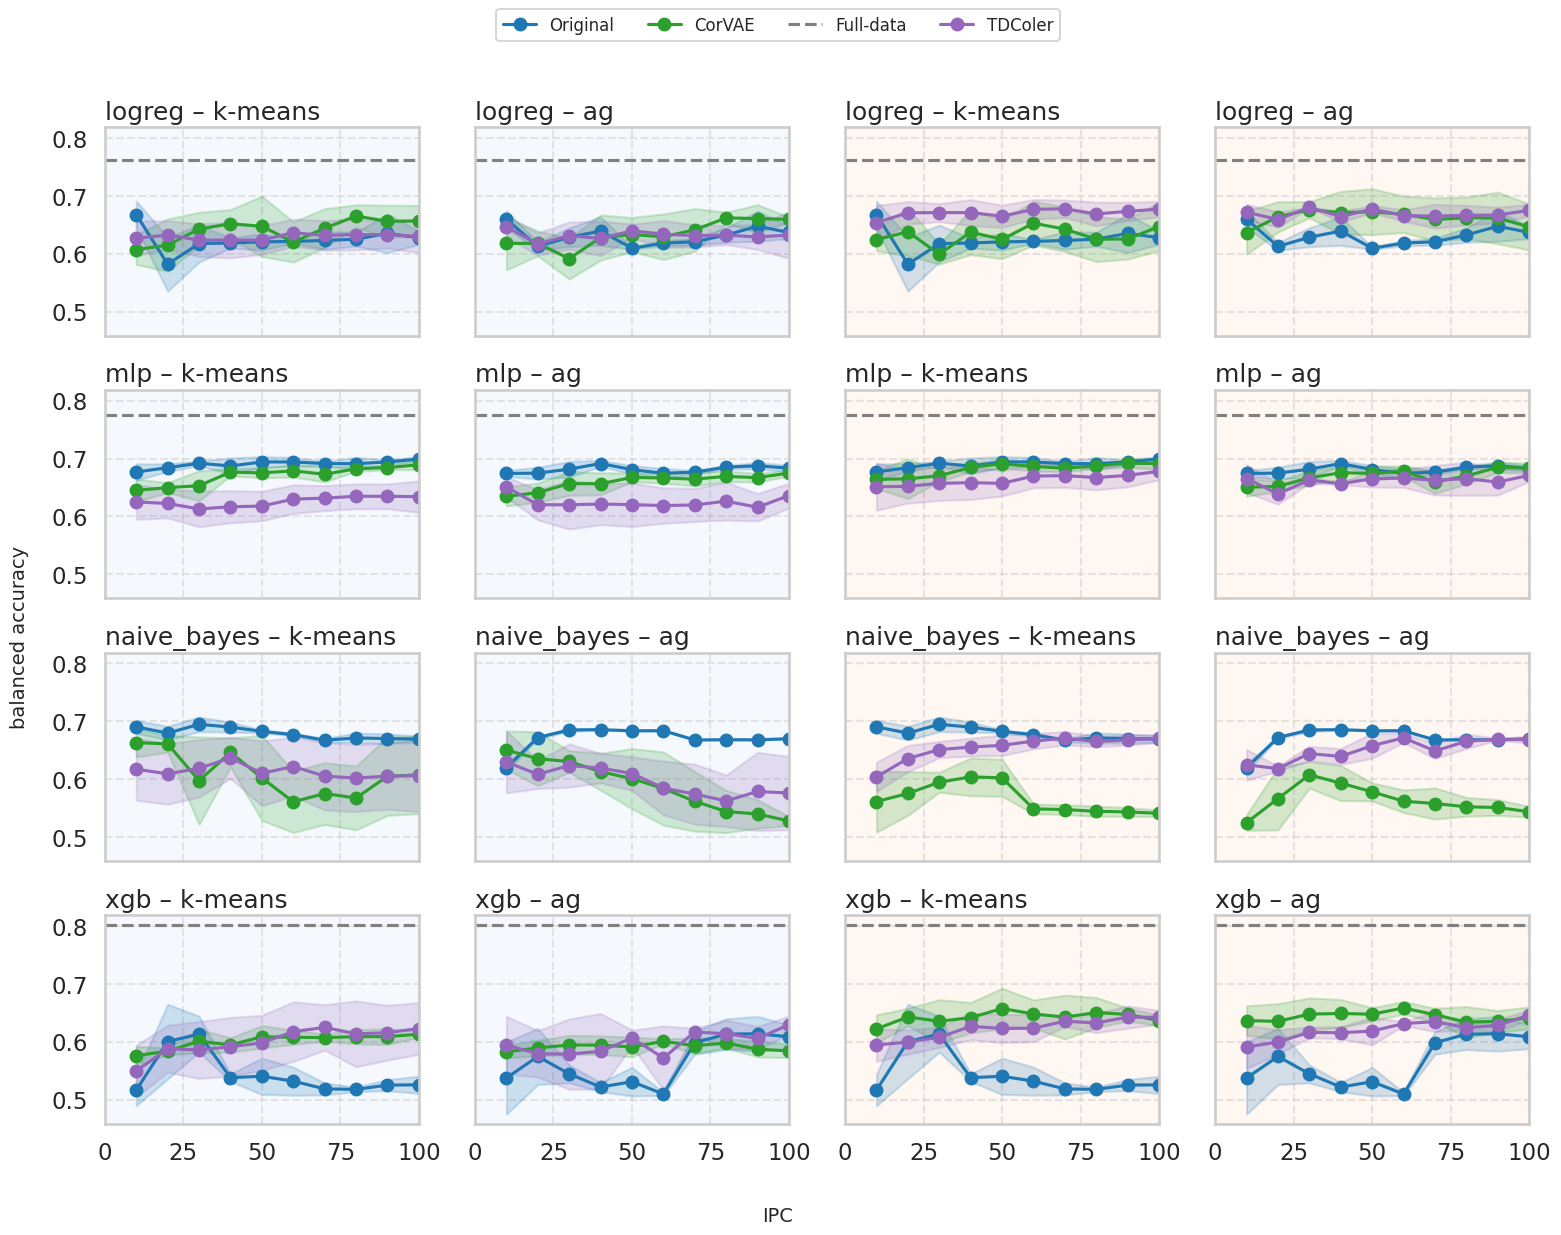

In [14]:
methods = ['k-means','ag']
models = ['logreg','mlp','naive_bayes','xgb']
plot_metric_grid_all(
    df_full=df_full_default[['model','method','IPC','test_balanced']],
    df_only_coreset=df_only_coreset_default[['model','method','IPC','test_balanced']],
    df_latent=df_latent_default[['model','method','IPC','test_balanced','space']],
    df_latent_ft=df_latent_ft_default[['model','method','IPC','test_balanced','space']],
    df_TDColer=df_tdcoler_latent_default,
    #space='original',      
    metric='test_balanced',
    methods=methods,
    models=models,
    x_label='IPC',
    y_label='balanced accuracy',
    name_savefig='metrics_figs/default_tdcoler_kg_test_balanced.png'
)

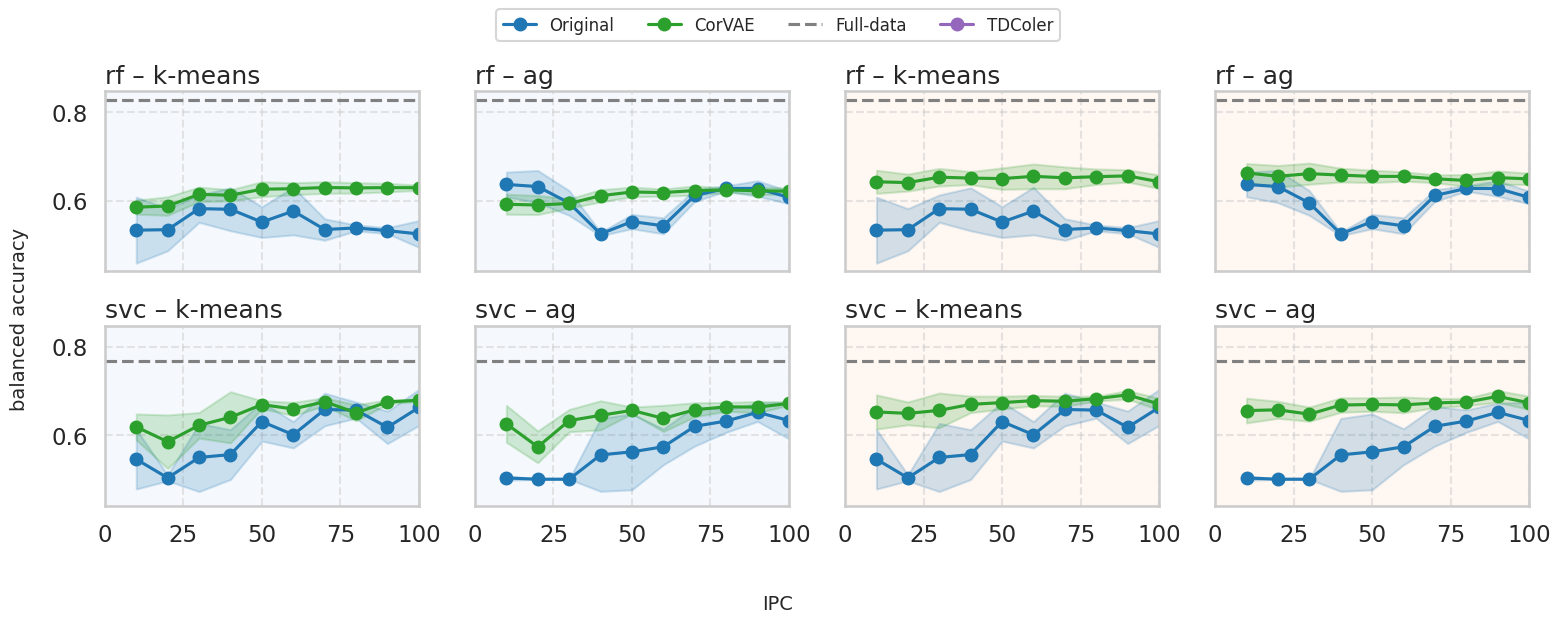

In [15]:
methods = ['k-means','ag']
models = ['rf','svc']
plot_metric_grid_all(
    df_full=df_full_default[['model','method','IPC','test_balanced']],
    df_only_coreset=df_only_coreset_default[['model','method','IPC','test_balanced']],
    df_latent=df_latent_default[['model','method','IPC','test_balanced','space']],
    df_latent_ft=df_latent_ft_default[['model','method','IPC','test_balanced','space']],
    df_TDColer=df_tdcoler_latent_default,
    #space='original',      
    metric='test_balanced',
    methods=methods,
    models=models,
    x_label='IPC',
    y_label='balanced accuracy',
    name_savefig='metrics_figs/default_kg_test_balanced.png'
)

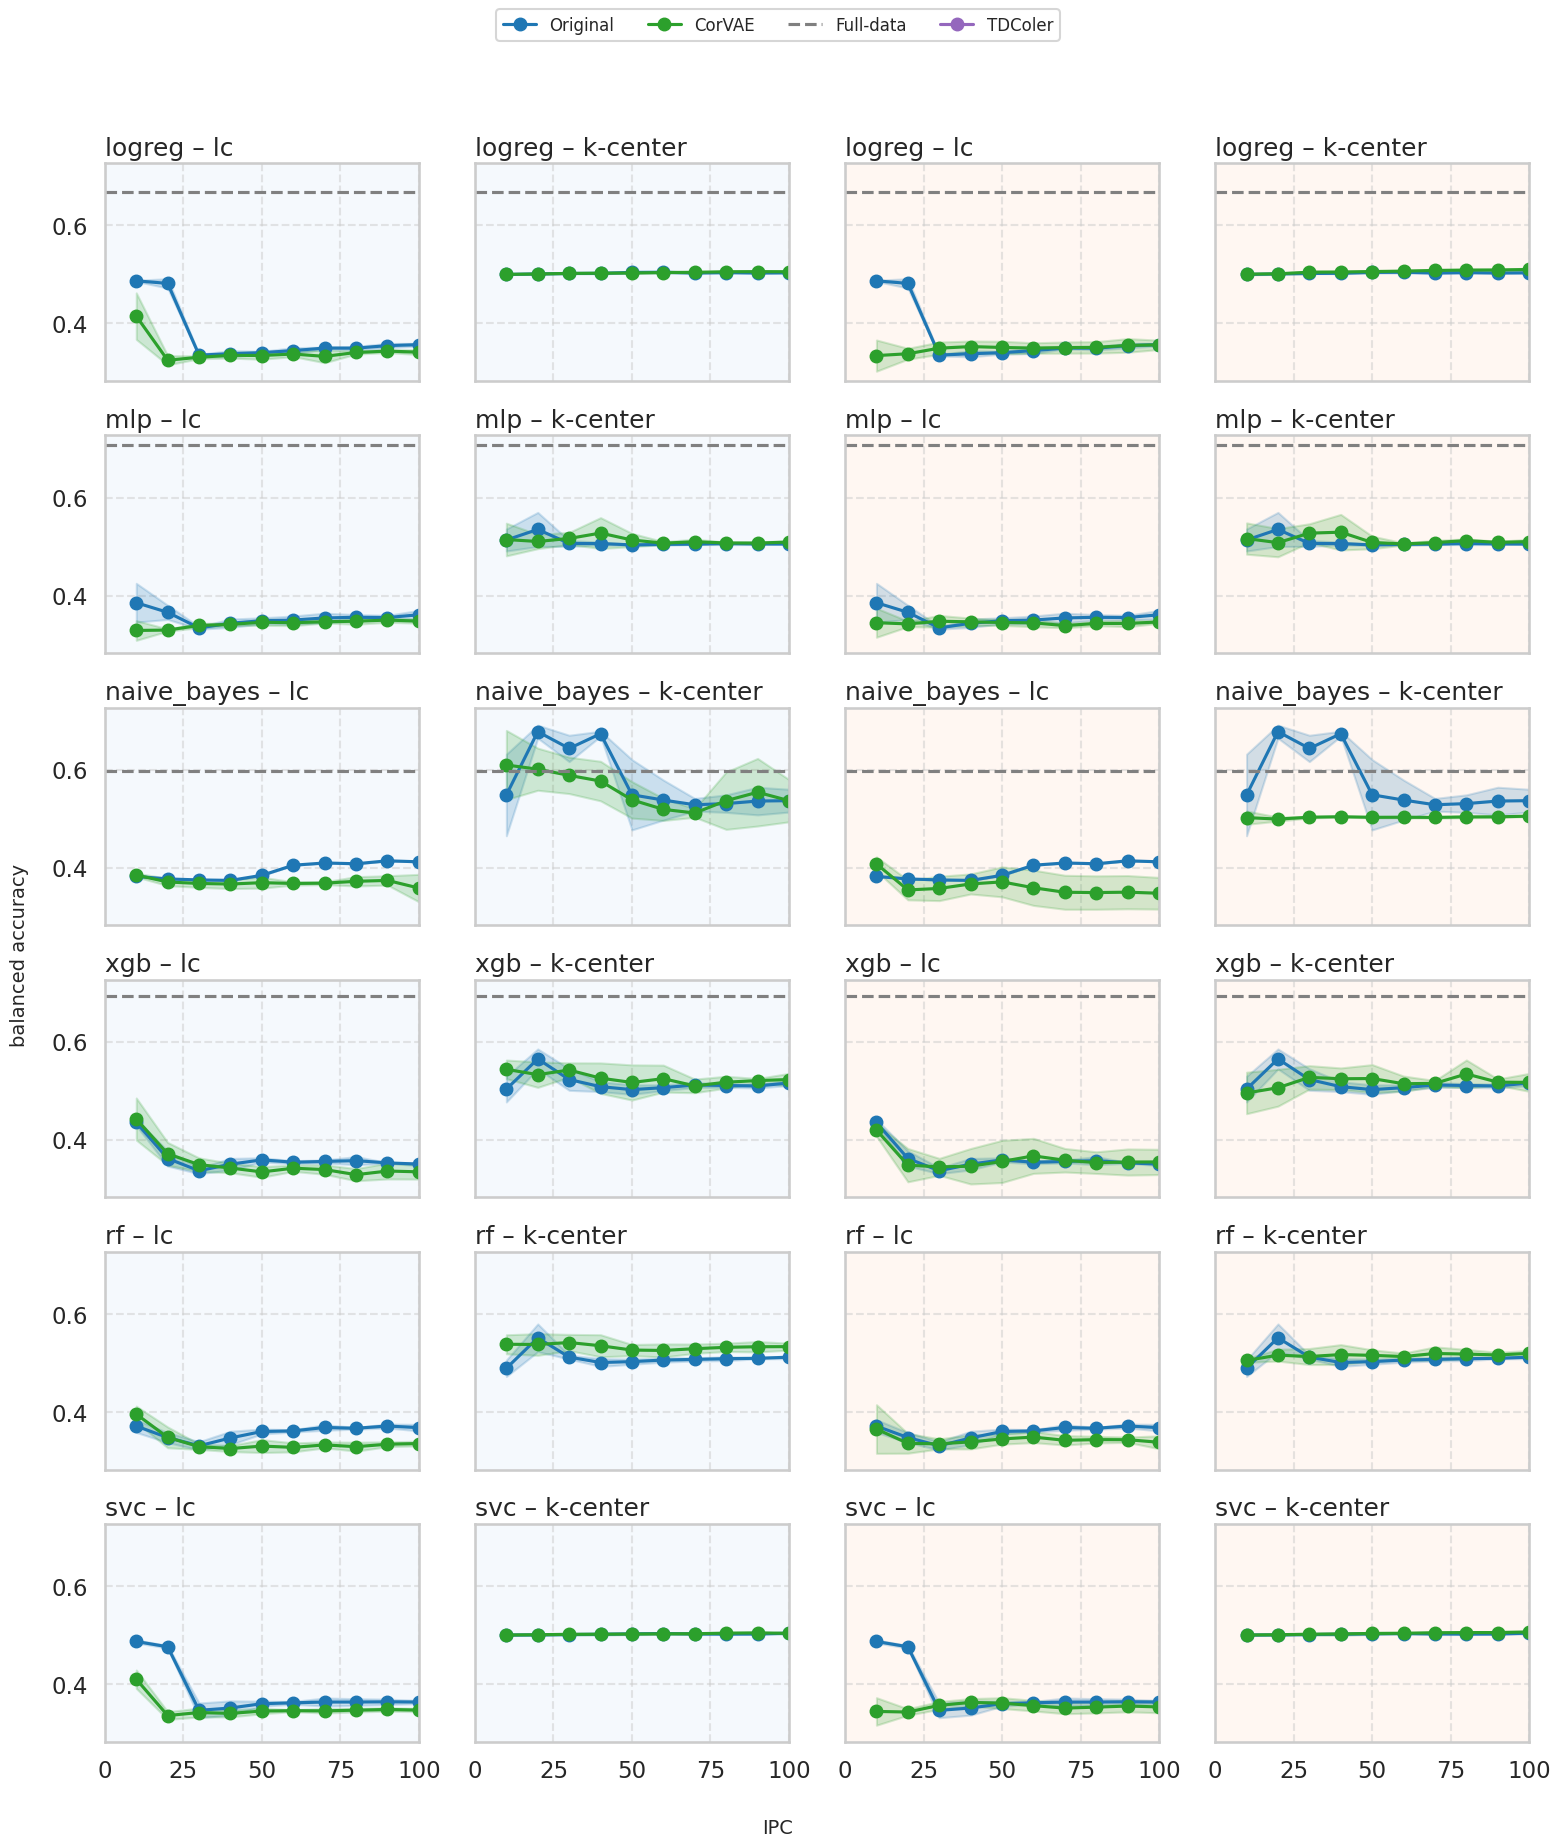

In [16]:
methods = ['lc','k-center']
models = ['logreg','mlp','naive_bayes','xgb','rf','svc']
plot_metric_grid_all(
    df_full=df_tdcoler_full_default,
    df_only_coreset=df_only_coreset_default[['model','method','IPC','test_balanced']],
    df_latent=df_latent_default[['model','method','IPC','test_balanced','space']],
    df_latent_ft=df_latent_ft_default[['model','method','IPC','test_balanced','space']],
    df_TDColer=df_tdcoler_latent_default,
    #space='original',      
    metric='test_balanced',
    methods=methods,
    models=models,
    x_label='IPC',
    y_label='balanced accuracy',
    name_savefig='metrics_figs/default_lck_test_balanced.png'
)

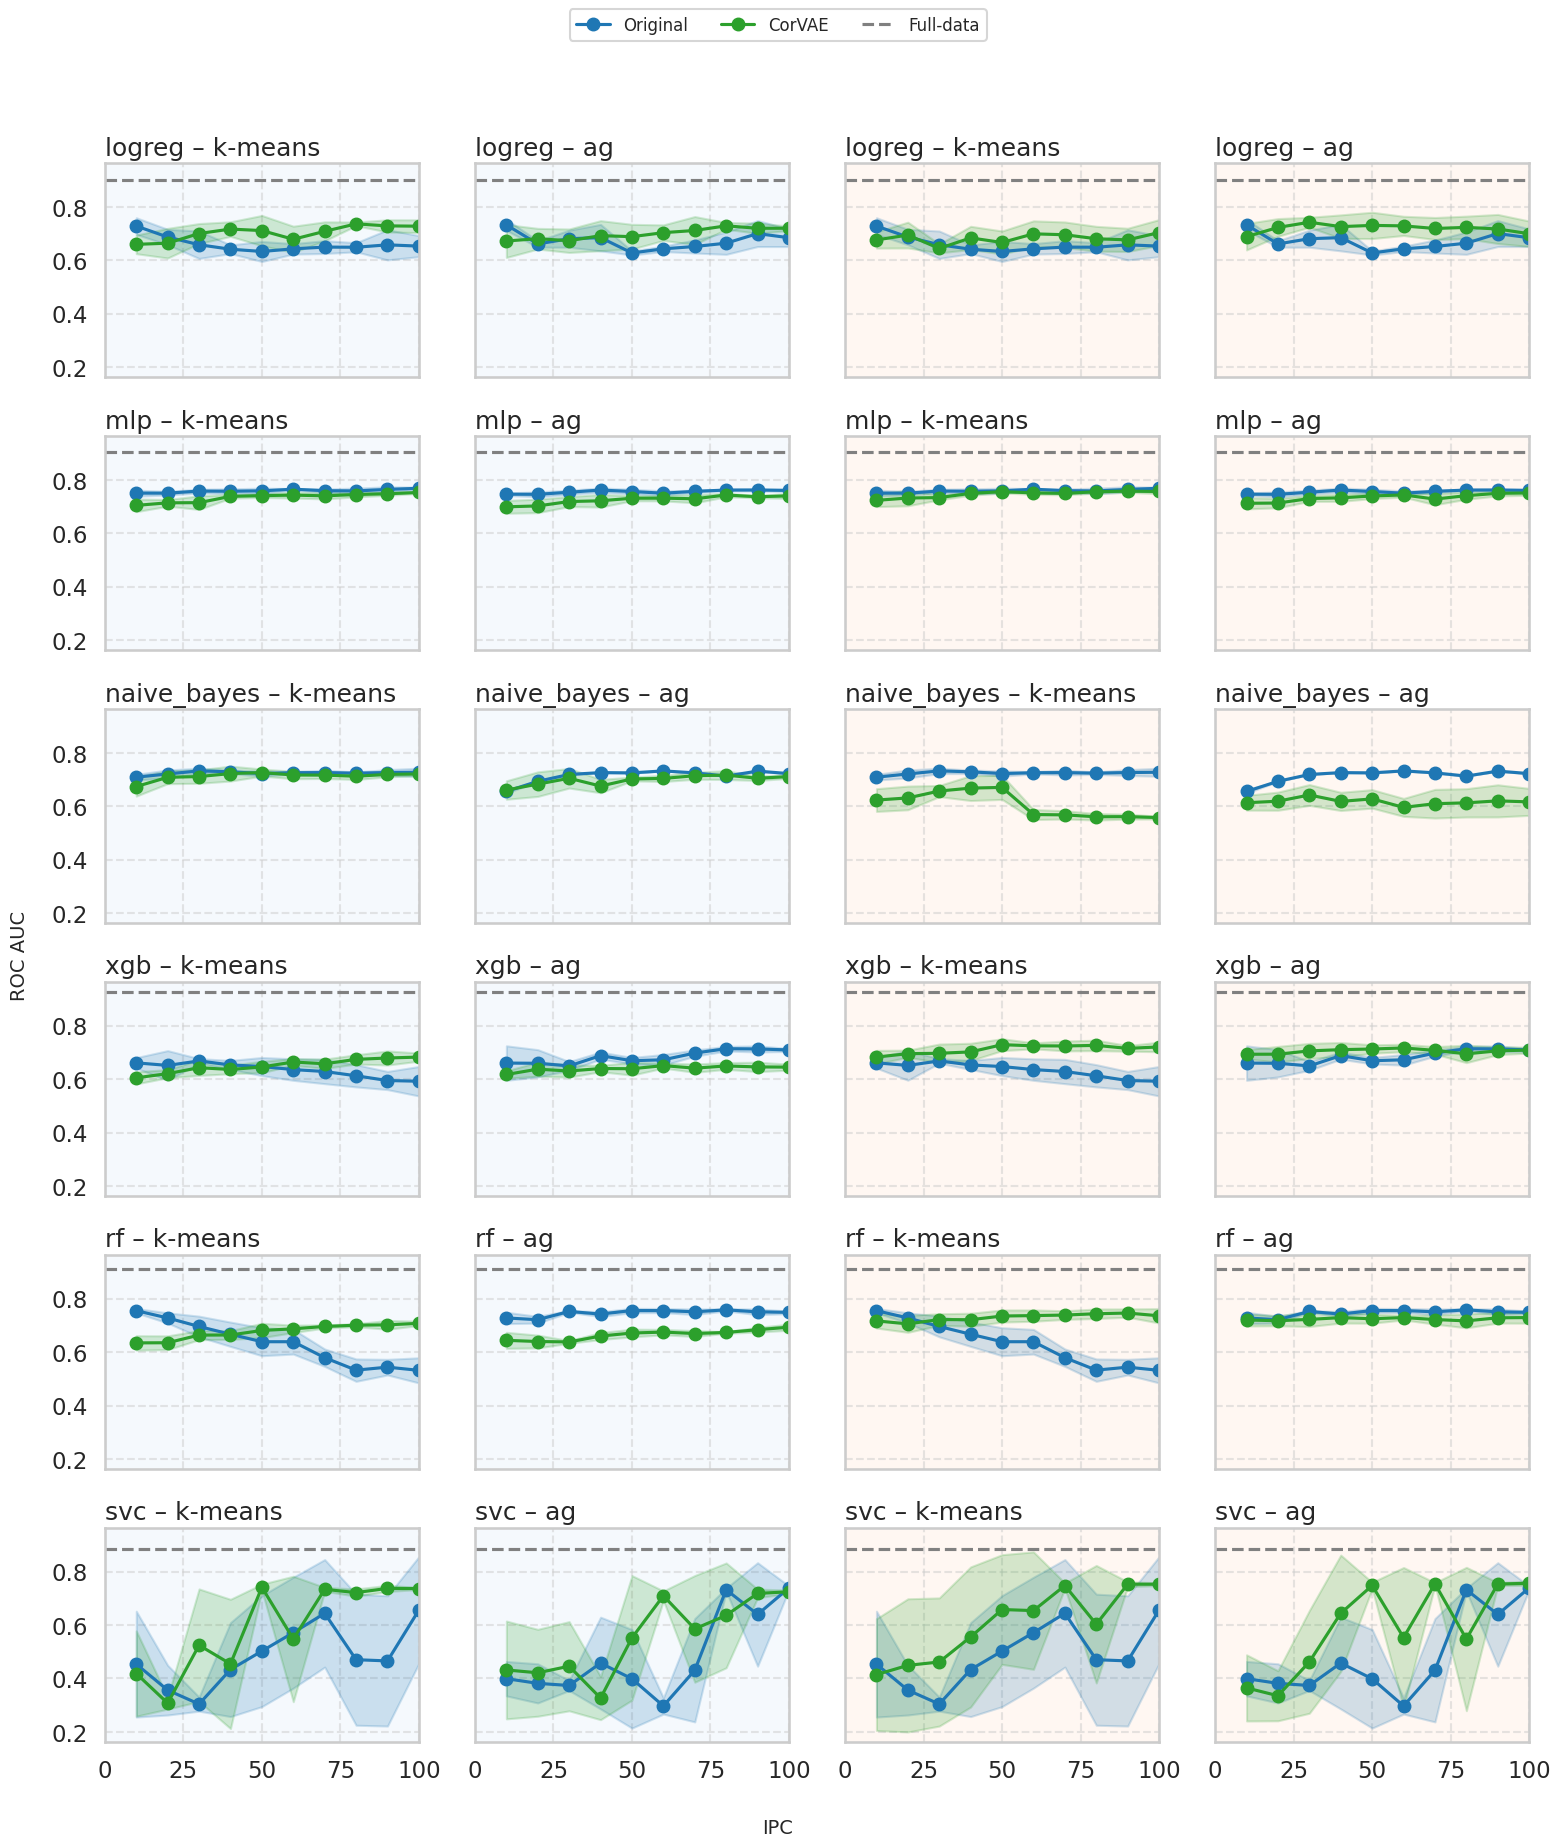

In [17]:
methods = ['k-means','ag']
models = ['logreg','mlp','naive_bayes','xgb','rf','svc']
plot_metric_grid_all(
    df_full=df_full_default[['model','method','IPC','test_roc_auc']],
    df_only_coreset=df_only_coreset_default[['model','method','IPC','test_roc_auc']],
    df_latent=df_latent_default[['model','method','IPC','test_roc_auc','space']],
    df_latent_ft=df_latent_ft_default[['model','method','IPC','test_roc_auc','space']],
    #df_TDColer=df_tdcoler_latent_default,
    #space='original',      
    metric='test_roc_auc',
    methods=methods,
    models=models,
    x_label='IPC',
    y_label='ROC AUC',
    name_savefig='metrics_figs/default_kg_roc_auc.png'
)

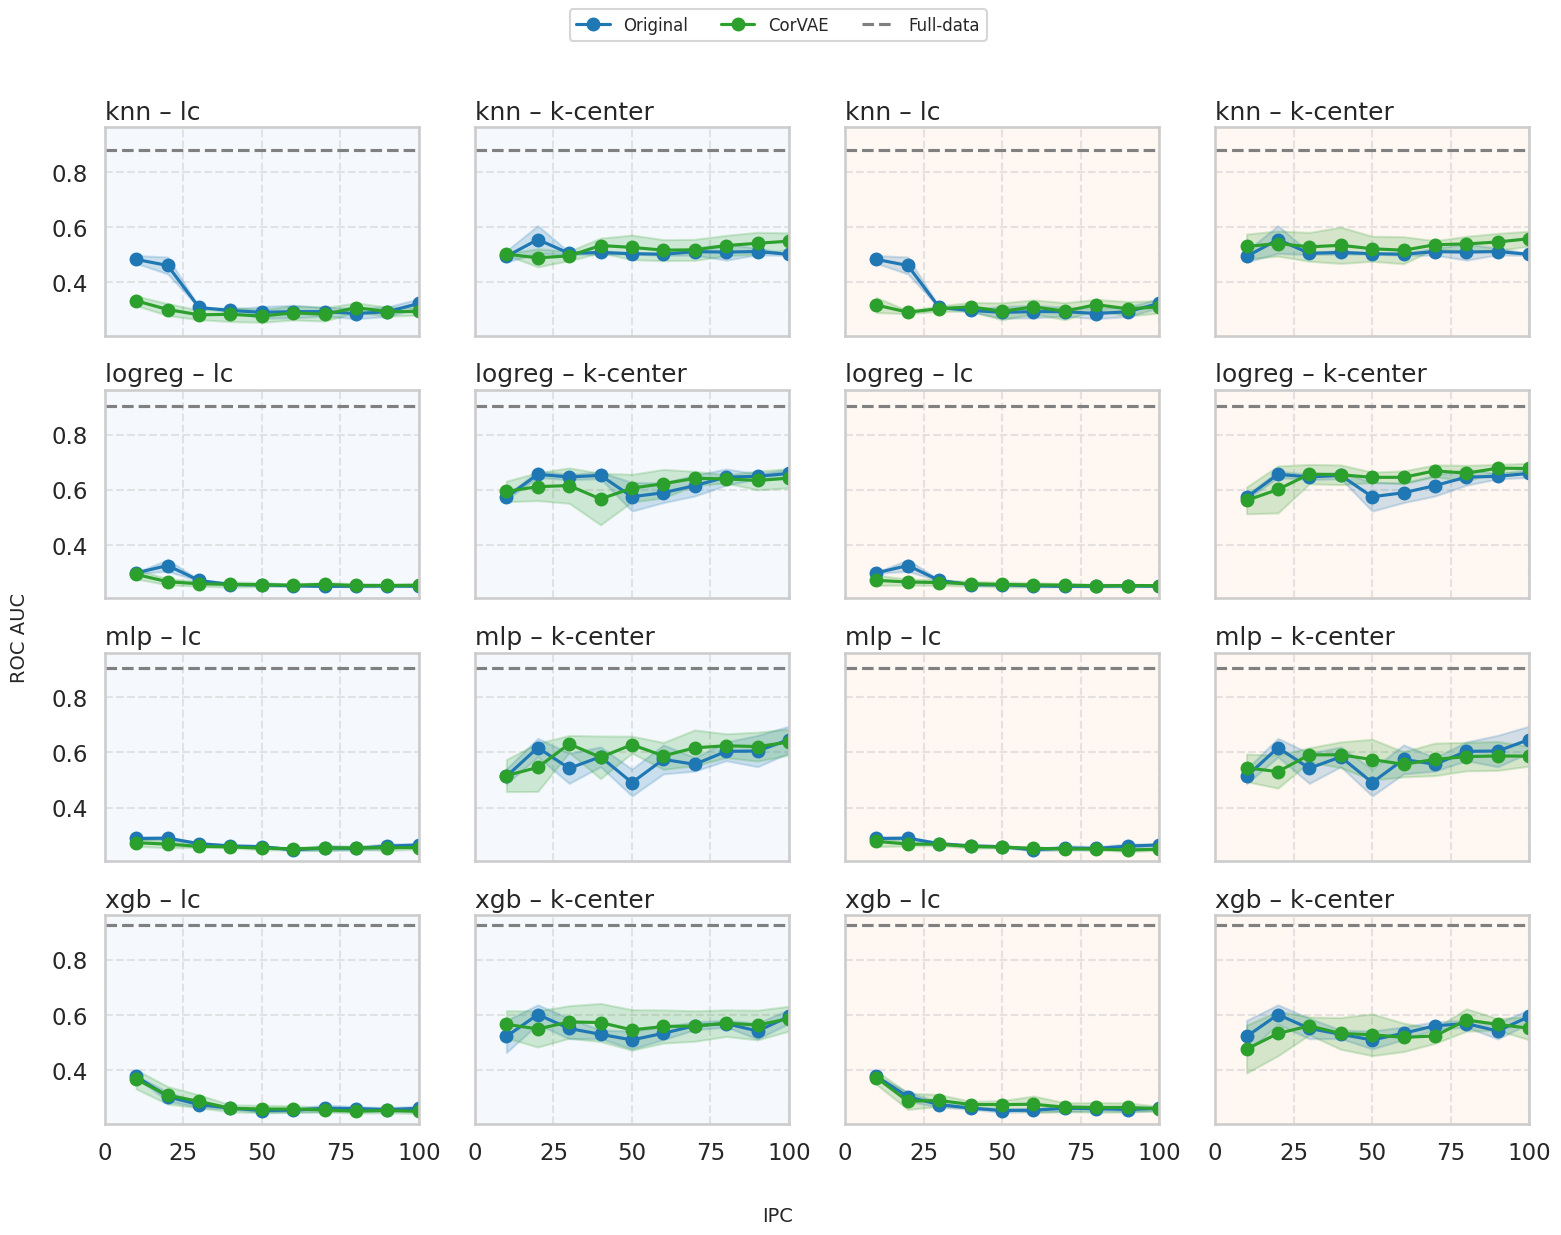

In [ ]:
methods = ['lc','k-center']
models = ['knn','logreg','mlp','xgb','rf','svc']
plot_metric_grid_all(
    df_full=df_full_default[['model','method','IPC','test_roc_auc']],
    df_only_coreset=df_only_coreset_default[['model','method','IPC','test_roc_auc']],
    df_latent=df_latent_default[['model','method','IPC','test_roc_auc','space']],
    df_latent_ft=df_latent_ft_default[['model','method','IPC','test_roc_auc','space']],
    #df_TDColer=df_tdcoler_latent_default,
    #space='original',      
    metric='test_roc_auc',
    methods=methods,
    models=models,
    x_label='IPC',
    y_label='ROC AUC',
    name_savefig='metrics_figs/default_lck_roc_auc.png'
)

## Dataset shopper

In [38]:
df_only_coreset_shoppers = pd.read_csv('Experiments_N/checkpoint_shoppers_Doriginal_F/metrics.csv')
df_only_coreset_shoppers['method'] = df_only_coreset_shoppers['method'].replace(
     'k_center', 'k-center'
)
df_full_shoppers = df_only_coreset_adult[df_only_coreset_adult['method'] == 'Full-data']
df_latent_shoppers = pd.read_csv('Experiments_N/checkpoint_shoppers_Dlatent_F/metrics.csv')
df_latent_ft_shoppers = pd.read_csv('Experiments_N/checkpoint_shoppers_Dlatent_ft_F/metrics.csv')

In [46]:
df_full_shoppers[['model','method','test_balanced','test_roc_auc']]

,model,method,test_balanced,test_roc_auc
0,xgb,Full-data,0.802,0.927
1,rf,Full-data,0.829,0.912
2,svc,Full-data,0.768,0.883
3,logreg,Full-data,0.762,0.902
4,mlp,Full-data,0.776,0.903


In [40]:
tabla = summarize_two_metrics(
    ipc=10,
    #metric='test_balanced',
    df_only_coreset=df_only_coreset_shoppers,
    df_latent=df_latent_shoppers,
    df_tdcoler=pd.DataFrame(),  # No TDColer para shoppers
    df_latent_ft=None
)
tabla

technique         space                 model test_balanced  \
method                                                              AG   
0             CorVAE       Latente   Regresión Logística   0.783±0.024   
1             CorVAE       Latente  Perceptrón Multicapa   0.747±0.018   
2             CorVAE       Latente     Ingenuo Bayesiano   0.720±0.073   
3             CorVAE       Latente      Bosque Aleatorio   0.812±0.013   
4             CorVAE       Latente                   svc   0.764±0.054   
5             CorVAE       Latente               XGBoost   0.764±0.078   
6             CorVAE  Reconstruido   Regresión Logística   0.795±0.017   
7             CorVAE  Reconstruido  Perceptrón Multicapa   0.782±0.013   
8             CorVAE  Reconstruido     Ingenuo Bayesiano   0.649±0.069   
9             CorVAE  Reconstruido      Bosque Aleatorio   0.728±0.015   
10            CorVAE  Reconstruido                   svc   0.797±0.022   
11            CorVAE  Reconstruido               XGBoost   0.785±0.074   
12      Sólo Coreset  Reconstruido   Regresión Logística   0.791±0.015   
13      Sólo Coreset  Reconstruido  Perceptrón Multicapa   0.753±0.010   
14      Sólo Coreset  Reconstruido     Ingenuo Bayesiano   0.585±0.002   
15      Sólo Coreset  Reconstruido      Bosque Aleatorio   0.680±0.029   
16      Sólo Coreset  Reconstruido                   svc   0.680±0.152   
17      Sólo Coreset  Reconstruido               XGBoost   0.756±0.082   

                                              test_roc_auc               \
method     K-center           KM           LC           AG     K-center   
0       0.492±0.004  0.788±0.036  0.275±0.024  0.865±0.029  0.496±0.030   
1       0.558±0.042  0.748±0.031  0.293±0.029  0.829±0.028  0.601±0.037   
2       0.584±0.078  0.642±0.061  0.301±0.051  0.740±0.087  0.623±0.128   
3       0.567±0.113  0.809±0.018  0.241±0.032  0.881±0.013  0.701±0.101   
4       0.499±0.003  0.789±0.050  0.298±0.050  0.637±0.343  0.468±0.025   
5       0.672±0.087  0.783±0.069  0.348±0.050  0.799±0.076  0.732±0.096   
6       0.490±0.003  0.798±0.014  0.248±0.036  0.882±0.012  0.514±0.051   
7       0.579±0.055  0.778±0.024  0.257±0.027  0.873±0.009  0.645±0.071   
8       0.559±0.043  0.627±0.034  0.411±0.045  0.659±0.079  0.553±0.041   
9       0.542±0.029  0.741±0.027  0.290±0.021  0.816±0.013  0.692±0.076   
10      0.498±0.003  0.816±0.019  0.266±0.037  0.896±0.014  0.441±0.071   
11      0.690±0.133  0.770±0.085  0.321±0.051  0.860±0.040  0.702±0.160   
12      0.489±0.006  0.804±0.006  0.449±0.008  0.875±0.016  0.473±0.035   
13      0.553±0.032  0.758±0.010  0.289±0.016  0.829±0.012  0.622±0.063   
14      0.468±0.016  0.583±0.019  0.340±0.001  0.587±0.001  0.488±0.019   
15      0.497±0.017  0.543±0.090  0.328±0.010  0.835±0.028  0.705±0.075   
16      0.500±0.000  0.647±0.154  0.418±0.038  0.641±0.340  0.500±0.006   
17      0.680±0.180  0.815±0.007  0.399±0.049  0.849±0.050  0.721±0.071   

                                  
method           KM           LC  
0       0.872±0.031  0.185±0.033  
1       0.827±0.035  0.225±0.027  
2       0.647±0.066  0.273±0.054  
3       0.885±0.020  0.155±0.025  
4       0.751±0.290  0.294±0.199  
5       0.823±0.053  0.284±0.081  
6       0.883±0.013  0.127±0.010  
7       0.859±0.023  0.180±0.025  
8       0.637±0.038  0.400±0.042  
9       0.826±0.022  0.194±0.021  
10      0.895±0.011  0.250±0.251  
11      0.859±0.046  0.227±0.067  
12      0.878±0.006  0.108±0.008  
13      0.842±0.008  0.177±0.005  
14      0.587±0.022  0.374±0.001  
15      0.853±0.019  0.267±0.017  
16      0.424±0.420  0.292±0.319  
17      0.846±0.030  0.315±0.008

In [41]:
tabla = summarize_two_metrics(
    ipc=50,
    #metric='test_balanced',
    df_only_coreset=df_only_coreset_shoppers,
    df_latent=df_latent_shoppers,
    df_tdcoler=pd.DataFrame(),  # No TDColer para shoppers
    df_latent_ft=None
)
tabla

technique         space                 model test_balanced  \
method                                                              AG   
0             CorVAE       Latente   Regresión Logística   0.776±0.049   
1             CorVAE       Latente  Perceptrón Multicapa   0.784±0.023   
2             CorVAE       Latente     Ingenuo Bayesiano   0.748±0.044   
3             CorVAE       Latente      Bosque Aleatorio   0.825±0.005   
4             CorVAE       Latente                   svc   0.803±0.023   
5             CorVAE       Latente               XGBoost   0.824±0.005   
6             CorVAE  Reconstruido   Regresión Logística   0.813±0.006   
7             CorVAE  Reconstruido  Perceptrón Multicapa   0.813±0.015   
8             CorVAE  Reconstruido     Ingenuo Bayesiano   0.641±0.044   
9             CorVAE  Reconstruido      Bosque Aleatorio   0.801±0.019   
10            CorVAE  Reconstruido                   svc   0.829±0.007   
11            CorVAE  Reconstruido               XGBoost   0.818±0.005   
12      Sólo Coreset  Reconstruido   Regresión Logística   0.638±0.032   
13      Sólo Coreset  Reconstruido  Perceptrón Multicapa   0.746±0.025   
14      Sólo Coreset  Reconstruido     Ingenuo Bayesiano   0.547±0.004   
15      Sólo Coreset  Reconstruido      Bosque Aleatorio   0.625±0.046   
16      Sólo Coreset  Reconstruido                   svc   0.755±0.005   
17      Sólo Coreset  Reconstruido               XGBoost   0.794±0.003   

                                              test_roc_auc               \
method     K-center           KM           LC           AG     K-center   
0       0.580±0.042  0.805±0.011  0.230±0.012  0.858±0.054  0.694±0.041   
1       0.620±0.048  0.796±0.018  0.270±0.009  0.869±0.018  0.714±0.065   
2       0.581±0.022  0.771±0.028  0.210±0.021  0.818±0.037  0.776±0.038   
3       0.805±0.045  0.818±0.010  0.222±0.047  0.896±0.007  0.876±0.020   
4       0.493±0.005  0.821±0.013  0.235±0.014  0.884±0.018  0.336±0.127   
5       0.795±0.052  0.822±0.006  0.230±0.077  0.869±0.030  0.862±0.034   
6       0.533±0.046  0.812±0.008  0.226±0.027  0.894±0.011  0.687±0.031   
7       0.603±0.015  0.794±0.013  0.244±0.019  0.887±0.008  0.734±0.031   
8       0.527±0.025  0.686±0.022  0.340±0.046  0.681±0.030  0.587±0.034   
9       0.807±0.033  0.795±0.015  0.241±0.030  0.875±0.008  0.879±0.014   
10      0.559±0.074  0.812±0.010  0.224±0.020  0.898±0.010  0.369±0.193   
11      0.779±0.067  0.819±0.007  0.252±0.064  0.883±0.005  0.863±0.024   
12      0.553±0.041  0.680±0.067  0.335±0.015  0.680±0.047  0.601±0.008   
13      0.608±0.040  0.770±0.017  0.267±0.005  0.813±0.016  0.681±0.050   
14      0.527±0.028  0.582±0.021  0.261±0.000  0.548±0.002  0.559±0.030   
15      0.739±0.037  0.500±0.000  0.256±0.008  0.875±0.009  0.848±0.019   
16      0.504±0.023  0.781±0.016  0.300±0.017  0.838±0.009  0.526±0.181   
17      0.737±0.025  0.563±0.105  0.219±0.018  0.882±0.006  0.818±0.017   

                                  
method           KM           LC  
0       0.889±0.010  0.138±0.019  
1       0.877±0.017  0.188±0.023  
2       0.823±0.028  0.157±0.026  
3       0.893±0.005  0.107±0.007  
4       0.892±0.013  0.140±0.012  
5       0.870±0.014  0.155±0.021  
6       0.889±0.008  0.105±0.012  
7       0.878±0.009  0.166±0.019  
8       0.737±0.039  0.253±0.050  
9       0.872±0.006  0.131±0.014  
10      0.885±0.011  0.108±0.013  
11      0.882±0.011  0.115±0.021  
12      0.748±0.077  0.099±0.009  
13      0.856±0.028  0.146±0.008  
14      0.572±0.029  0.218±0.000  
15      0.882±0.013  0.177±0.003  
16      0.884±0.021  0.109±0.028  
17      0.873±0.015  0.113±0.003

In [42]:
tabla = summarize_two_metrics(
    ipc=100,
    #metric='test_balanced',
    df_only_coreset=df_only_coreset_shoppers,
    df_latent=df_latent_shoppers,
    df_tdcoler=pd.DataFrame(),  # No TDColer para shoppers
    df_latent_ft=None
)
tabla

technique         space                 model test_balanced  \
method                                                              AG   
0             CorVAE       Latente   Regresión Logística   0.806±0.009   
1             CorVAE       Latente  Perceptrón Multicapa   0.799±0.012   
2             CorVAE       Latente     Ingenuo Bayesiano   0.738±0.036   
3             CorVAE       Latente      Bosque Aleatorio   0.832±0.005   
4             CorVAE       Latente                   svc   0.817±0.010   
5             CorVAE       Latente               XGBoost   0.834±0.005   
6             CorVAE  Reconstruido   Regresión Logística   0.821±0.005   
7             CorVAE  Reconstruido  Perceptrón Multicapa   0.812±0.011   
8             CorVAE  Reconstruido     Ingenuo Bayesiano   0.640±0.033   
9             CorVAE  Reconstruido      Bosque Aleatorio   0.815±0.006   
10            CorVAE  Reconstruido                   svc   0.828±0.009   
11            CorVAE  Reconstruido               XGBoost   0.826±0.005   
12      Sólo Coreset  Reconstruido   Regresión Logística   0.651±0.024   
13      Sólo Coreset  Reconstruido  Perceptrón Multicapa   0.766±0.009   
14      Sólo Coreset  Reconstruido     Ingenuo Bayesiano   0.558±0.007   
15      Sólo Coreset  Reconstruido      Bosque Aleatorio   0.734±0.020   
16      Sólo Coreset  Reconstruido                   svc   0.774±0.005   
17      Sólo Coreset  Reconstruido               XGBoost   0.806±0.017   

                                              test_roc_auc               \
method     K-center           KM           LC           AG     K-center   
0       0.641±0.059  0.802±0.021  0.221±0.022  0.884±0.013  0.762±0.052   
1       0.628±0.030  0.802±0.006  0.232±0.012  0.880±0.006  0.731±0.033   
2       0.594±0.021  0.762±0.022  0.177±0.022  0.817±0.032  0.776±0.022   
3       0.833±0.003  0.829±0.006  0.207±0.037  0.898±0.006  0.896±0.008   
4       0.616±0.038  0.818±0.006  0.221±0.025  0.888±0.010  0.703±0.119   
5       0.785±0.031  0.826±0.004  0.201±0.024  0.892±0.009  0.864±0.026   
6       0.602±0.025  0.820±0.002  0.219±0.027  0.896±0.010  0.740±0.046   
7       0.649±0.020  0.805±0.015  0.220±0.009  0.892±0.005  0.774±0.016   
8       0.533±0.017  0.691±0.026  0.368±0.035  0.719±0.021  0.624±0.039   
9       0.826±0.015  0.811±0.013  0.237±0.049  0.882±0.003  0.891±0.009   
10      0.582±0.083  0.823±0.007  0.223±0.029  0.900±0.006  0.500±0.298   
11      0.804±0.043  0.824±0.007  0.217±0.045  0.890±0.013  0.870±0.028   
12      0.557±0.074  0.755±0.025  0.289±0.009  0.708±0.029  0.665±0.018   
13      0.613±0.035  0.774±0.004  0.248±0.009  0.845±0.015  0.701±0.038   
14      0.551±0.018  0.574±0.014  0.253±0.003  0.574±0.007  0.611±0.007   
15      0.799±0.027  0.500±0.000  0.245±0.006  0.897±0.004  0.877±0.016   
16      0.532±0.074  0.768±0.018  0.262±0.010  0.847±0.006  0.667±0.068   
17      0.781±0.016  0.504±0.011  0.215±0.006  0.897±0.002  0.856±0.011   

                                  
method           KM           LC  
0       0.887±0.020  0.112±0.008  
1       0.891±0.010  0.144±0.006  
2       0.843±0.016  0.124±0.030  
3       0.899±0.010  0.103±0.005  
4       0.893±0.016  0.109±0.007  
5       0.889±0.024  0.169±0.025  
6       0.896±0.008  0.093±0.003  
7       0.888±0.008  0.115±0.010  
8       0.748±0.030  0.194±0.058  
9       0.880±0.004  0.110±0.006  
10      0.896±0.008  0.093±0.003  
11      0.885±0.026  0.106±0.005  
12      0.834±0.022  0.085±0.007  
13      0.855±0.007  0.113±0.006  
14      0.576±0.010  0.164±0.000  
15      0.876±0.018  0.142±0.002  
16      0.865±0.018  0.090±0.006  
17      0.858±0.019  0.109±0.004

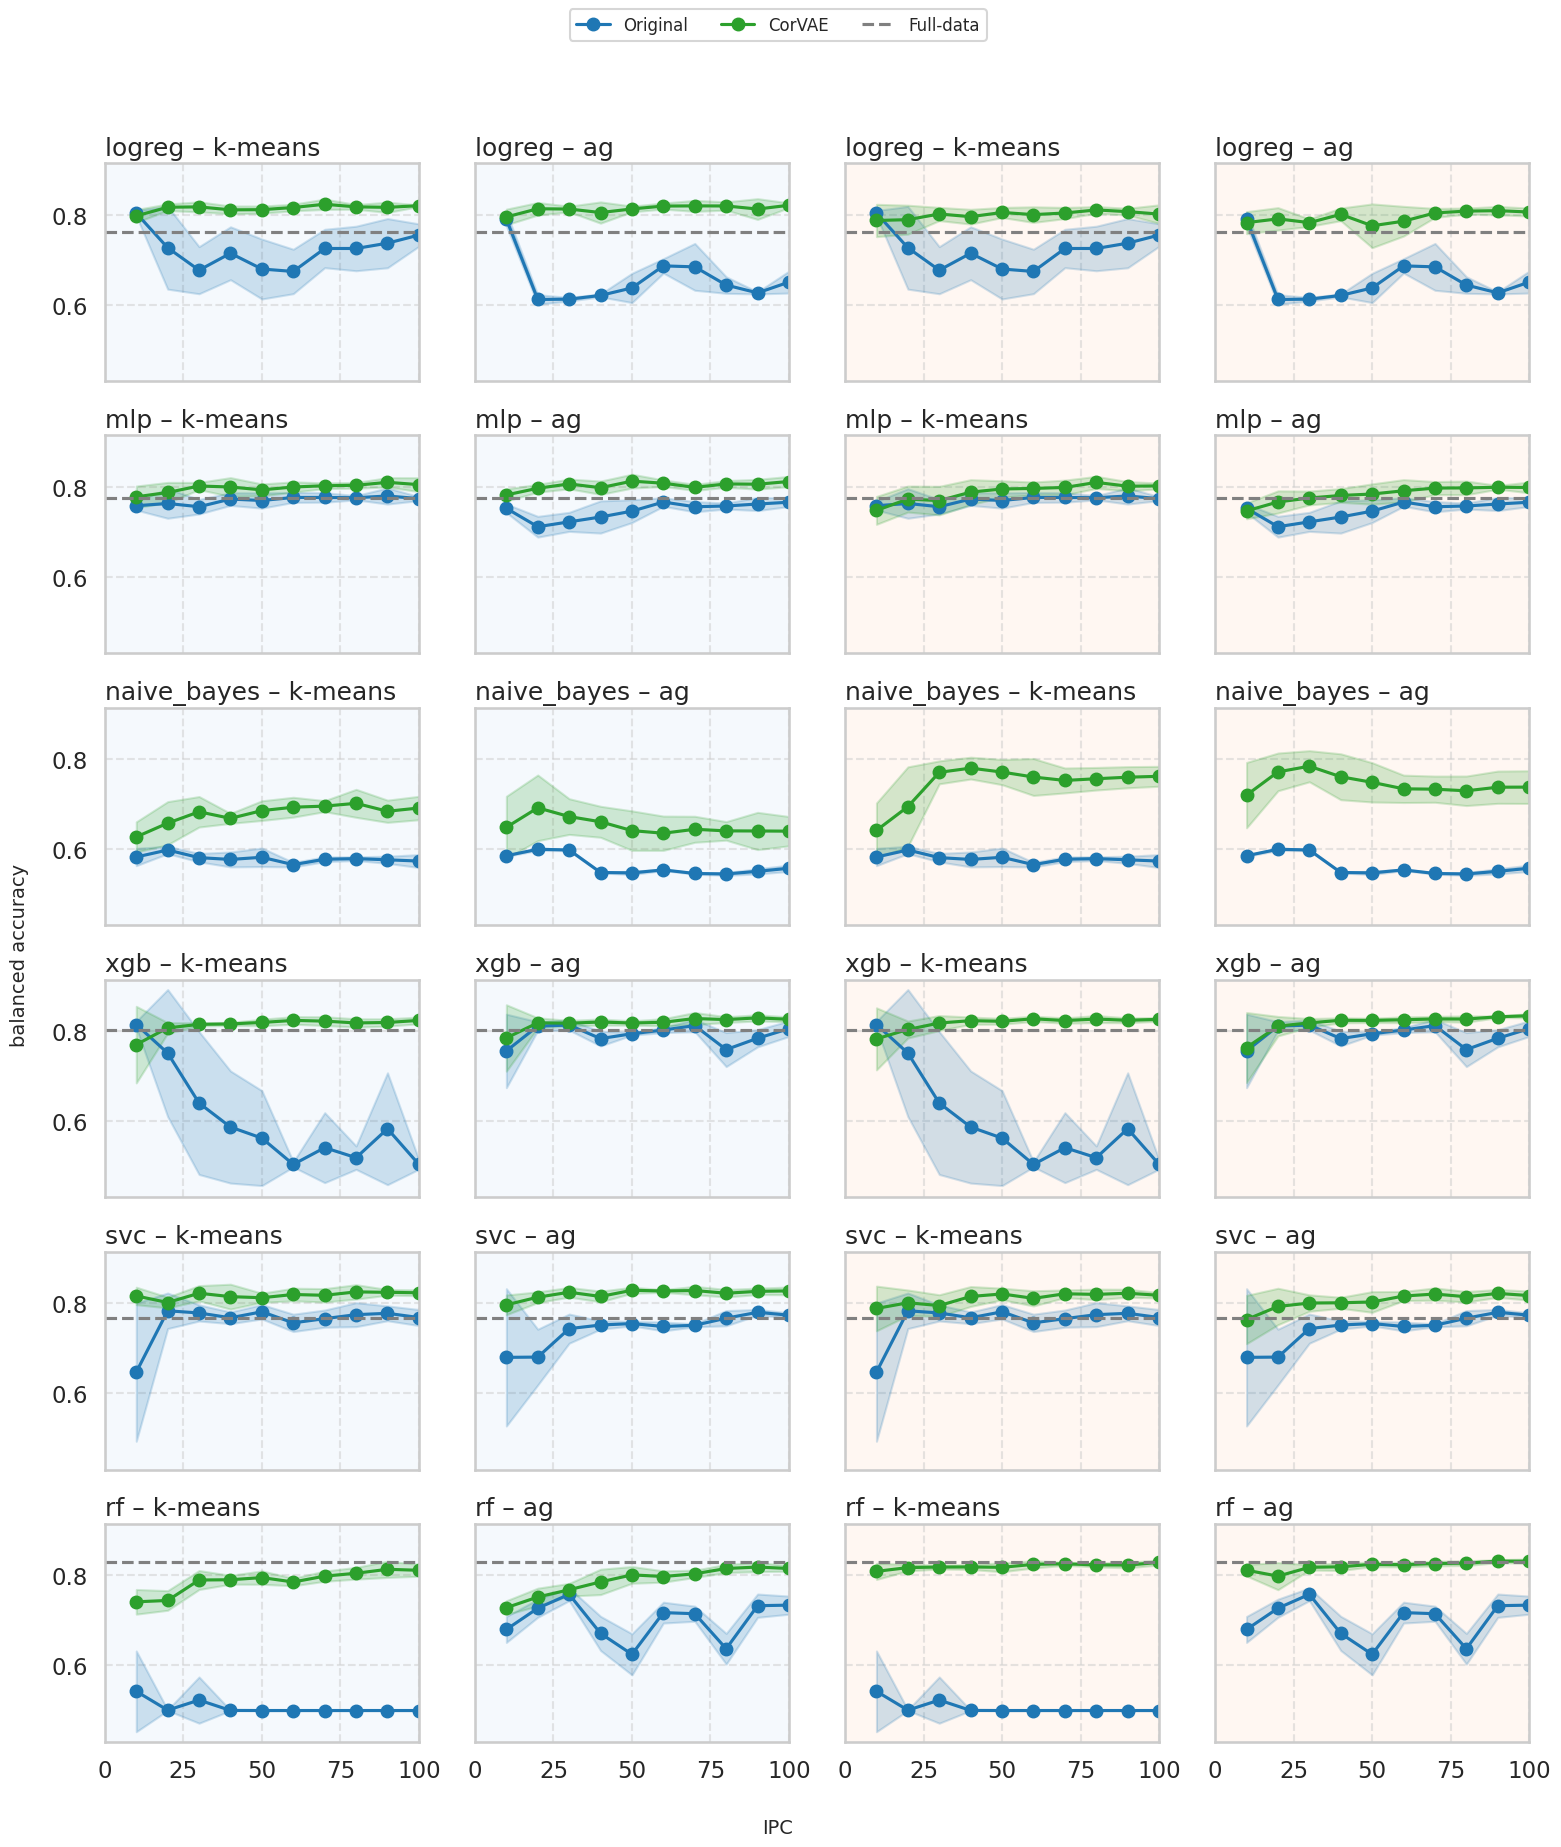

In [19]:
methods = ['k-means','ag']
models = ['logreg','mlp','naive_bayes','xgb','svc','rf']
plot_metric_grid_all(
    df_full=df_full_shoppers[['model','method','IPC','test_balanced']],
    df_only_coreset=df_only_coreset_shoppers[['model','method','IPC','test_balanced']],
    df_latent=df_latent_shoppers[['model','method','IPC','test_balanced','space']],
    df_latent_ft=df_latent_ft_shoppers[['model','method','IPC','test_balanced','space']],
    #df_TDColer=df_tdcoler_latent_default,
    #space='original',      
    metric='test_balanced',
    methods=methods,
    models=models,
    x_label='IPC',
    y_label='balanced accuracy',
    name_savefig='metrics_figs/shoppers_kg_balanced.png'
)

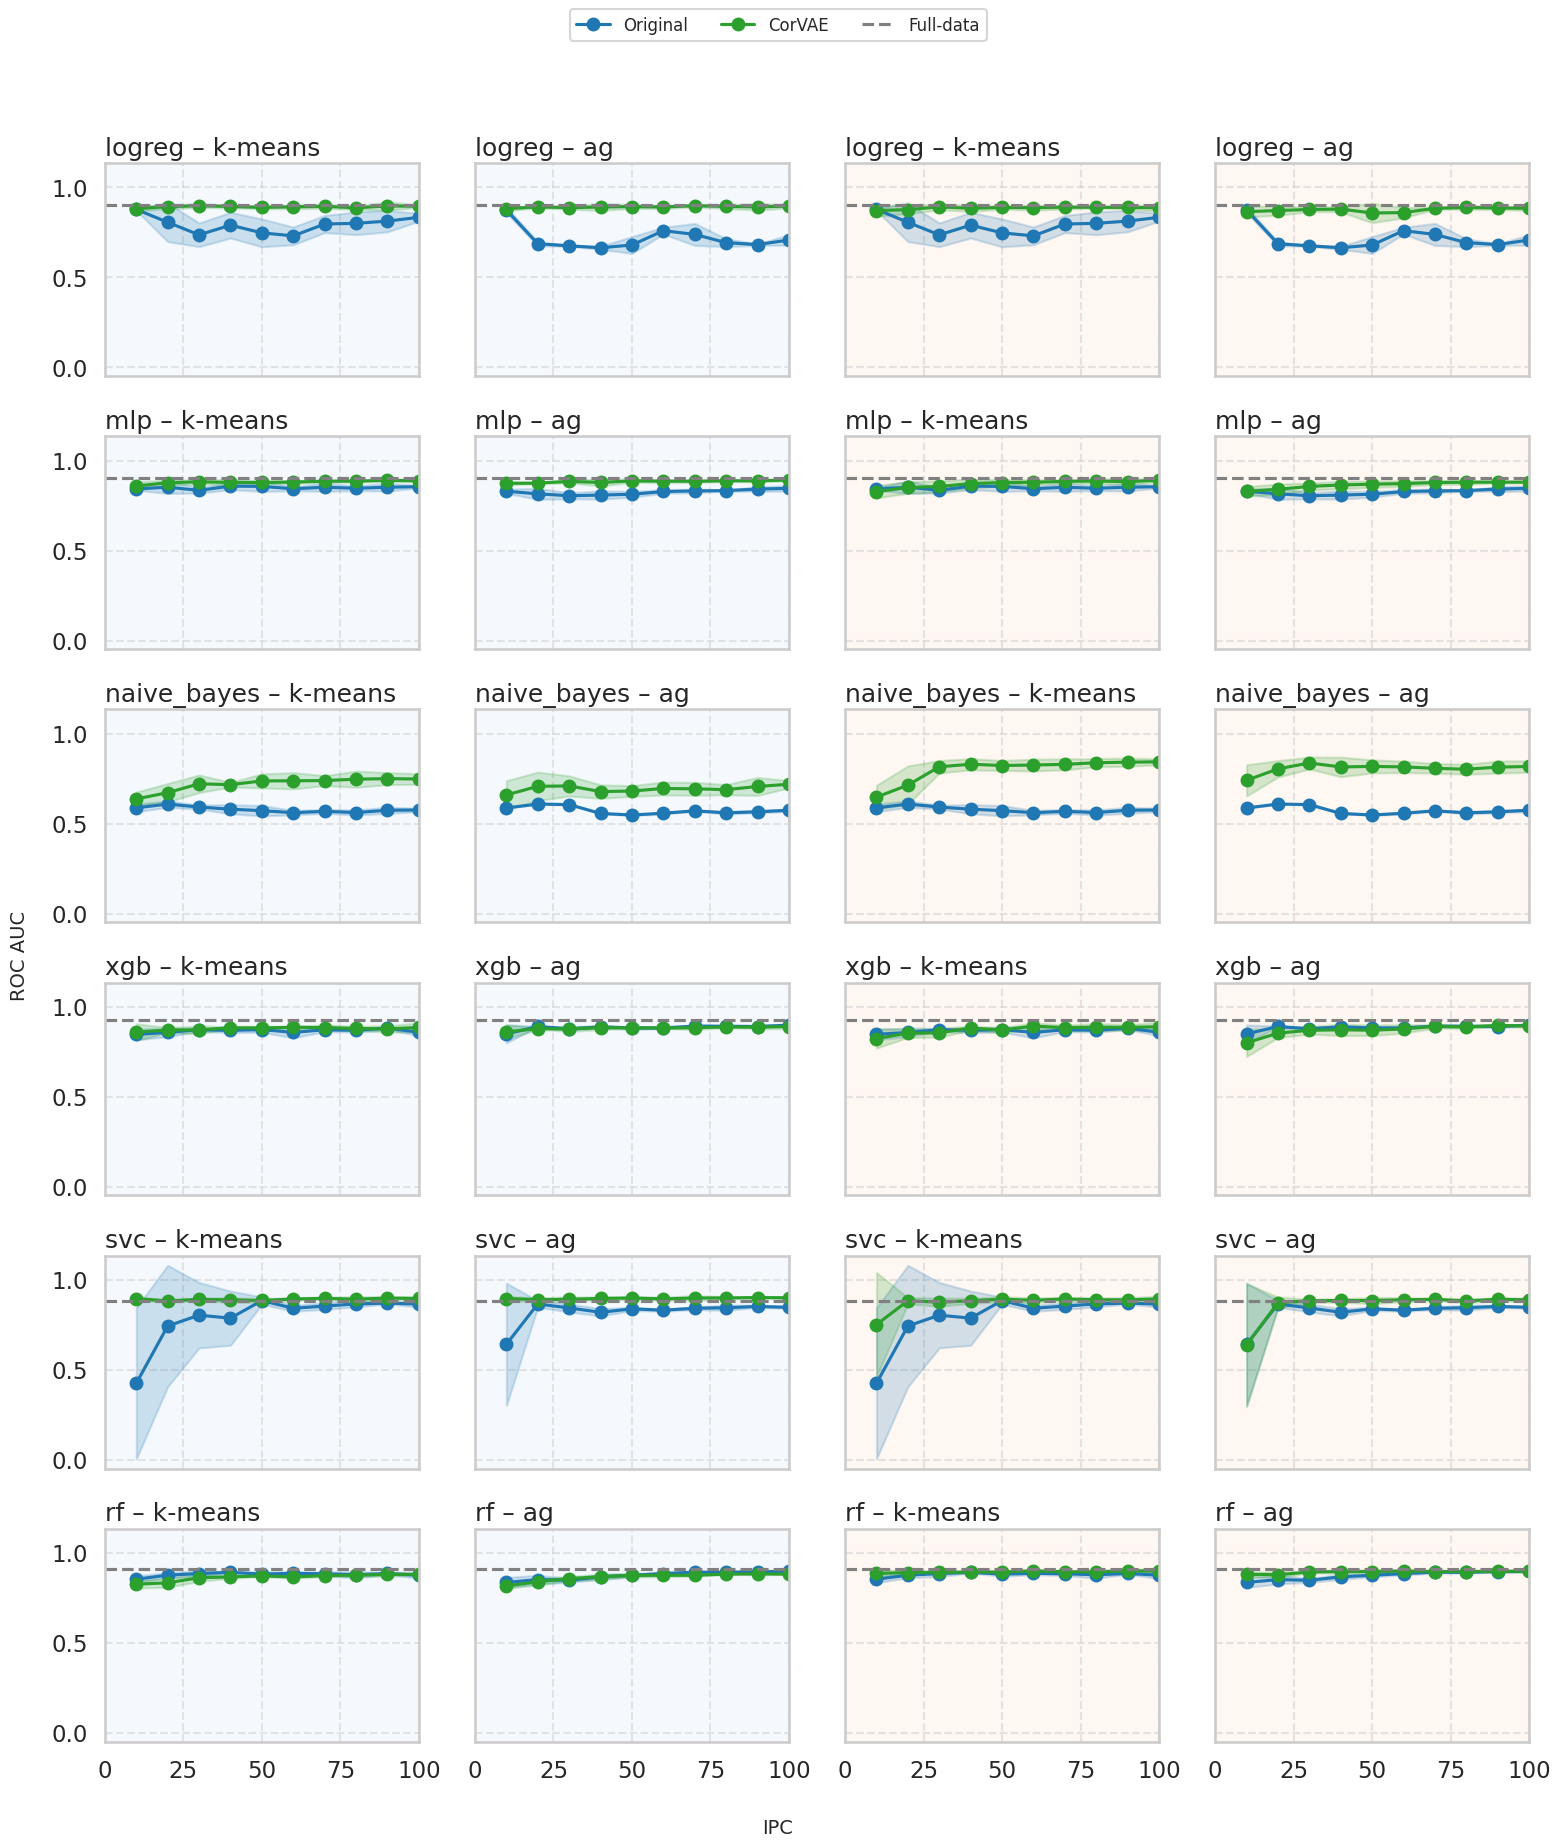

In [20]:
methods = ['k-means','ag']
models =['logreg','mlp','naive_bayes','xgb','svc','rf']
plot_metric_grid_all(
    df_full=df_full_shoppers[['model','method','IPC','test_roc_auc']],
    df_only_coreset=df_only_coreset_shoppers[['model','method','IPC','test_roc_auc']],
    df_latent=df_latent_shoppers[['model','method','IPC','test_roc_auc','space']],
    df_latent_ft=df_latent_ft_shoppers[['model','method','IPC','test_roc_auc','space']],
    #df_TDColer=df_tdcoler_latent_default,
    #space='original',      
    metric='test_roc_auc',
    methods=methods,
    models=models,
    x_label='IPC',
    y_label='ROC AUC',
    name_savefig='metrics_figs/shoppers_kg_roc_auc.png'
)

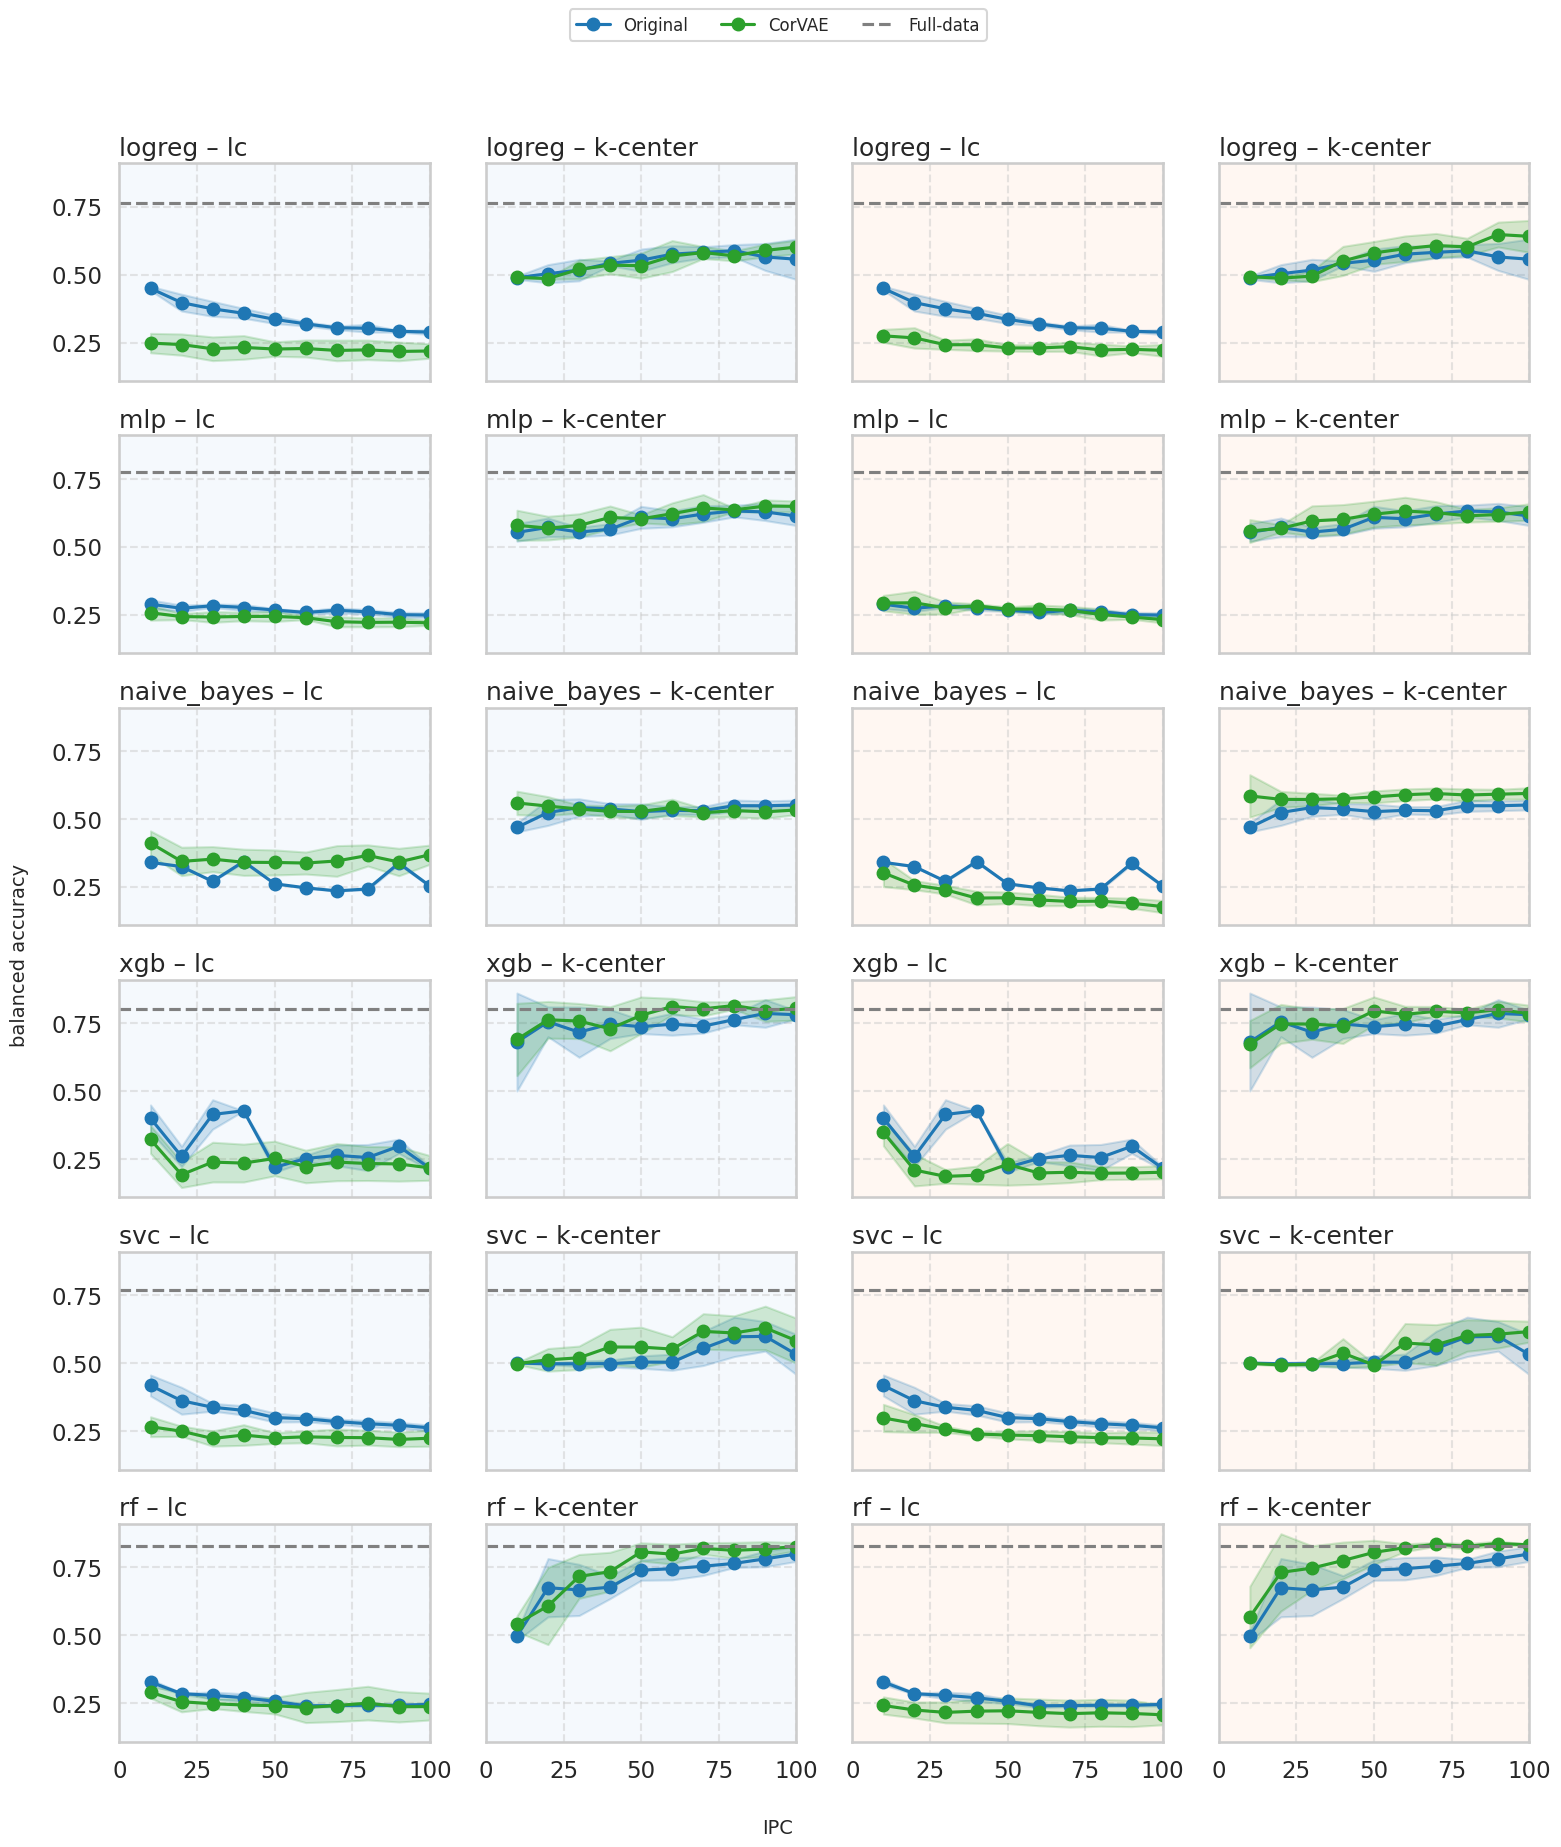

In [21]:
methods = ['lc','k-center']
models = ['logreg','mlp','naive_bayes','xgb','svc','rf']
plot_metric_grid_all(
    df_full=df_full_shoppers[['model','method','IPC','test_balanced']],
    df_only_coreset=df_only_coreset_shoppers[['model','method','IPC','test_balanced']],
    df_latent=df_latent_shoppers[['model','method','IPC','test_balanced','space']],
    df_latent_ft=df_latent_ft_shoppers[['model','method','IPC','test_balanced','space']],
    #df_TDColer=df_tdcoler_latent_shoppers,
    #space='original',      
    metric='test_balanced',
    methods=methods,
    models=models,
    x_label='IPC',
    y_label='balanced accuracy',
    name_savefig='metrics_figs/shoppers_lck_balanced.png'
)

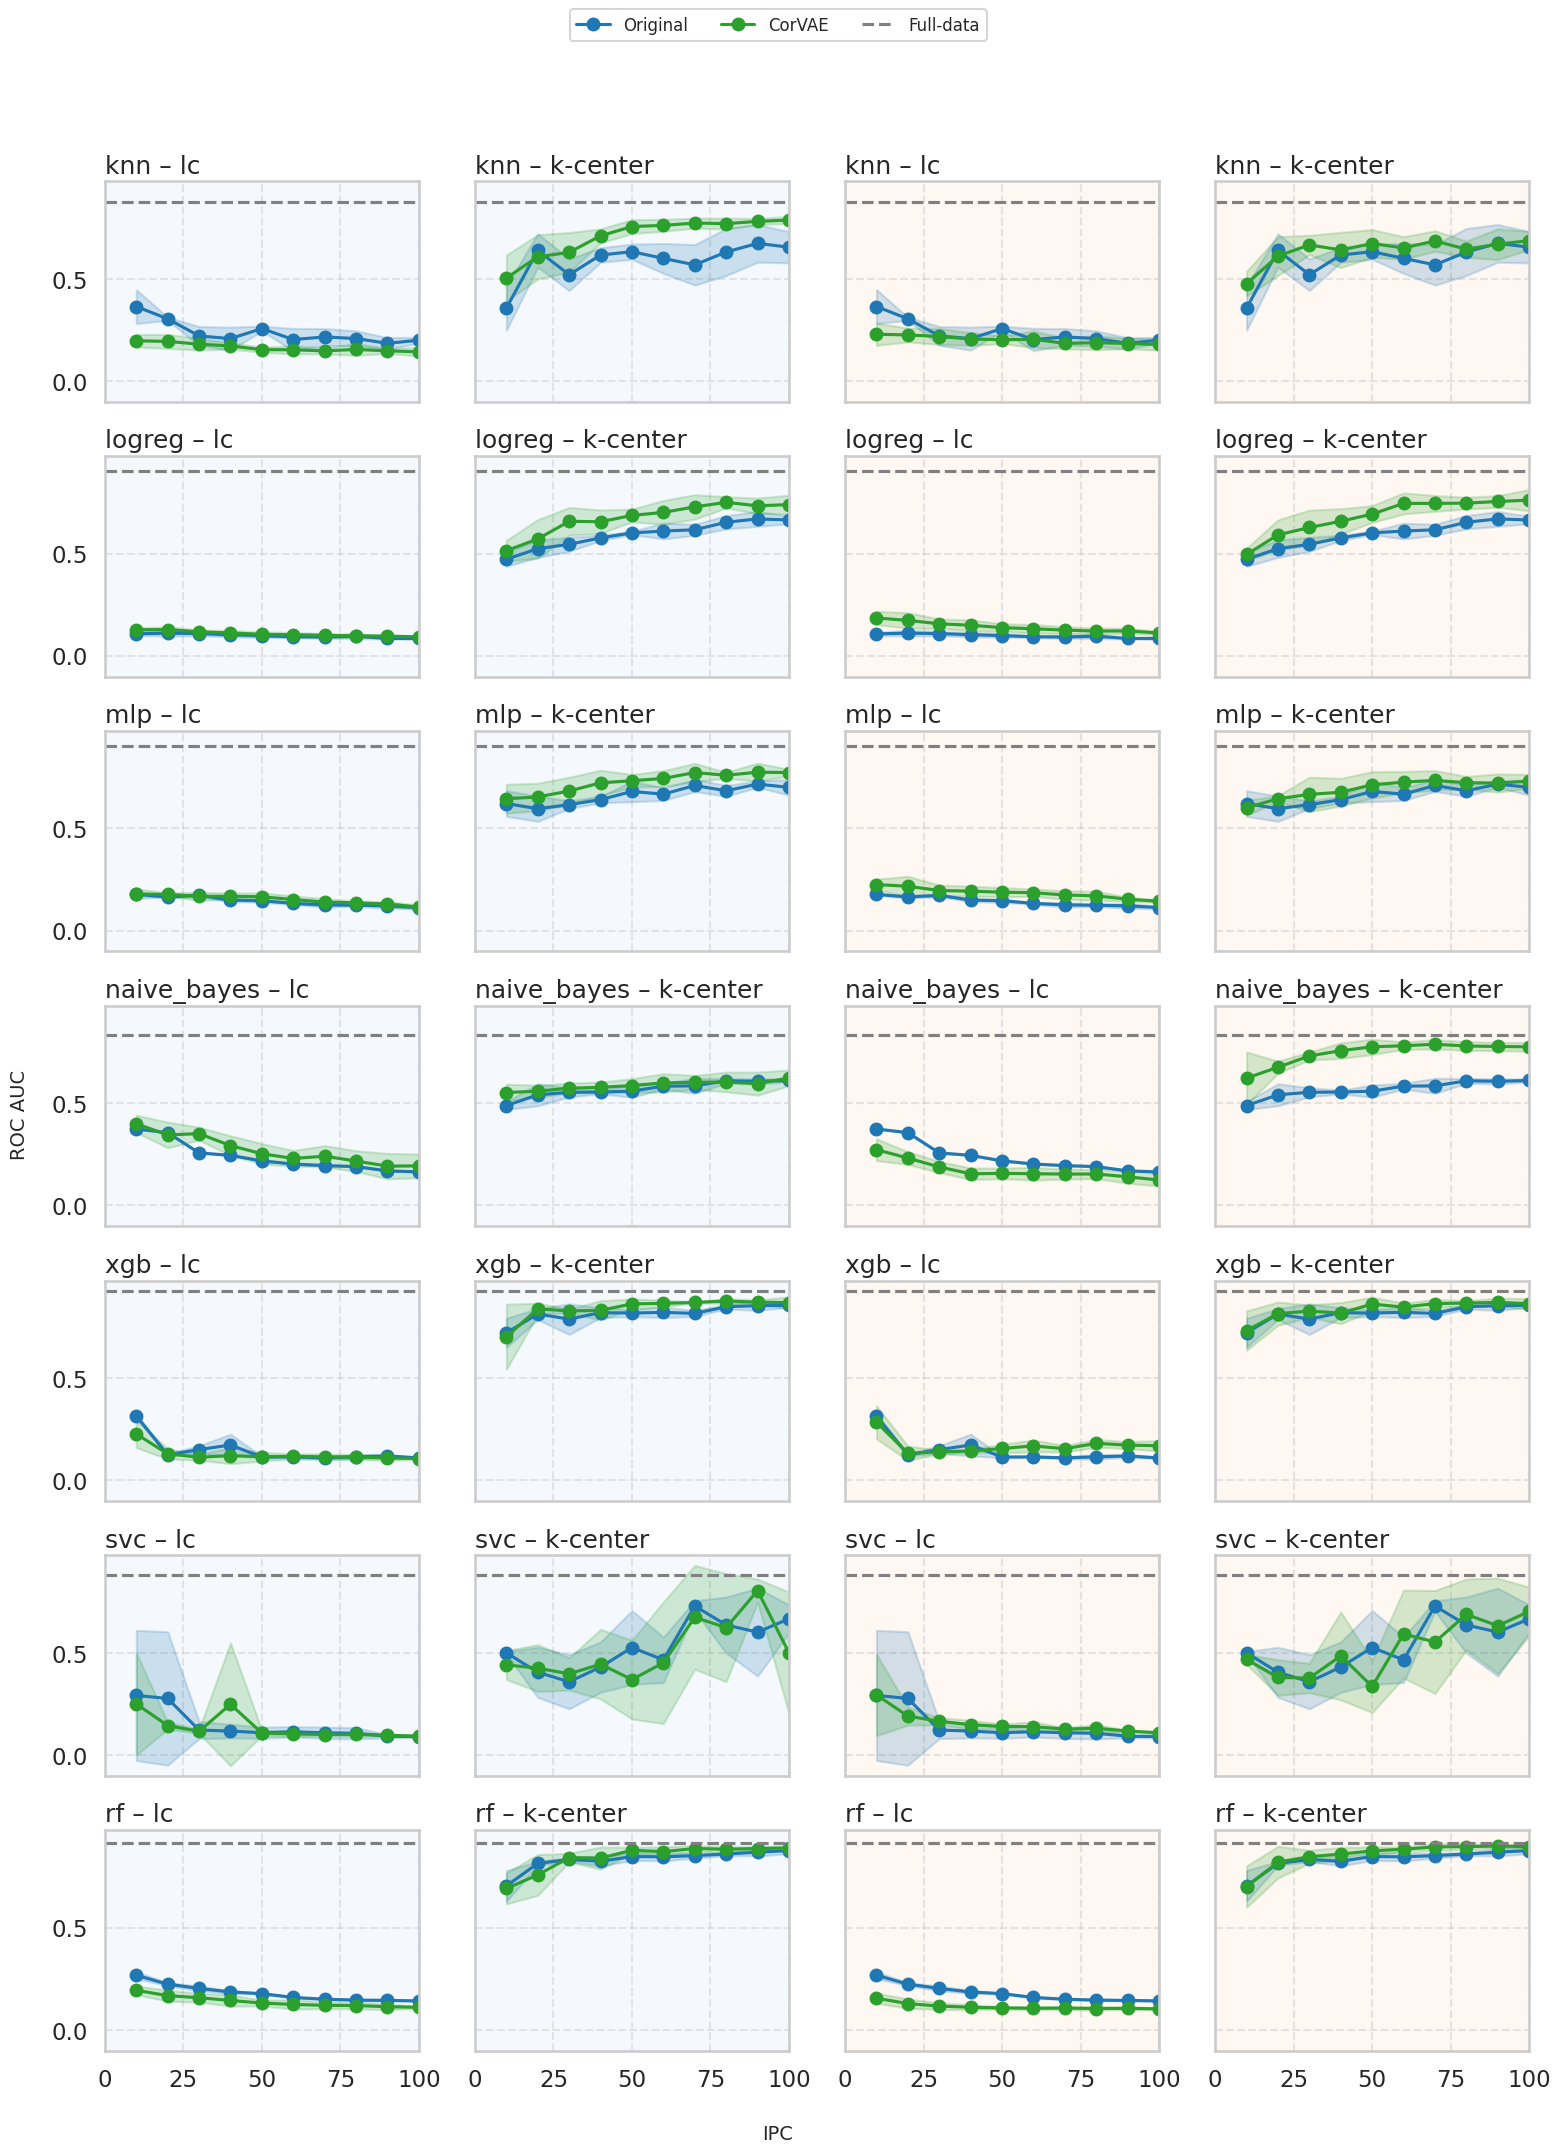

In [27]:
methods = ['lc','k-center']
models = ['knn','logreg','mlp','naive_bayes','xgb','svc','rf']
plot_metric_grid_all(
    df_full=df_full_shoppers[['model','method','IPC','test_roc_auc']],
    df_only_coreset=df_only_coreset_shoppers[['model','method','IPC','test_roc_auc']],
    df_latent=df_latent_shoppers[['model','method','IPC','test_roc_auc','space']],
    df_latent_ft=df_latent_ft_shoppers[['model','method','IPC','test_roc_auc','space']],
    #df_TDColer=df_tdcoler_latent_shoppers,
    #space='original',      
    metric='test_roc_auc',
    methods=methods,
    models=models,
    x_label='IPC',
    y_label='ROC AUC',
    name_savefig='metrics_figs/shoppers_tdcoler_original_kg_roc_auc.png'
)